# SIF × Irrigation × Drought — Iowa 2015–2024

## Overview

This notebook investigates whether irrigation decouples plant productivity from drought
stress in Iowa cropland over a 10-year period (2015–2024).

**Core hypothesis:** In heavily irrigated cropland, plants maintain high SIF even during
drought because irrigation supplies water. In rainfed cropland, drought suppresses SIF
as expected. The 10-year window captures multiple drought cycles and a range of irrigation
responses.

### Datasets

| Dataset | Variable | Period | Resolution |
|---|---|---|---|
| **ΔET (irrigation signal)** | OpenET − NLDAS Noah | 2015–2024 monthly | 0.125° Iowa grid |
| **SIF (plant productivity)** | OCO-2 v11r `sif_ann` | 2015–2024 monthly | 0.05° → reprojected to 0.125° |
| **NDVI (greenness index)** | MODIS MOD13A3 | 2015–2024 monthly | 1 km → reprojected to 0.125° |
| **Drought** | US Drought Monitor biweekly GeoTIFFs | 2015–2024 | County → 0.125° |
| **Cropland mask** | USDA CDL-derived, annual | 2015–2024 | 0.125° |

### Irrigation classification threshold

Based on ET product measurement uncertainty:
- **ΔET > +20 mm/month** = **High-confidence irrigation** (signal exceeds noise floor)
- **ΔET ≤ +20 mm/month** = **Low-confidence or no irrigation** (within measurement noise)

### Notebook sections

1. Setup
2. NLDAS Iowa reference grid
3. Helper functions (ET, SIF, NDVI, drought, mask loaders)
4. Build 10-year monthly aligned dataset
5. Compute pixel-level z-scores
6. Build analysis DataFrame (growing season, cropland filter)
7. Z-score time series with drought overlay
8. Violin plots: SIF and ΔET distributions by drought category
9. Irrigation buffering analysis (high vs low ΔET) — 20 mm threshold
10. SIF × ΔET scatter colored by drought
11. 2D SIF heatmap: irrigation level × drought severity
12. Irrigation buffering gap curve
13. **NDVI analysis** — repeat sections 7–12 using NDVI instead of SIF + fallow detection
14. **Corn vs. Soy** — CDL-based classification, separate SIF/ΔET/drought figures
15. Summary

## 1. Setup and Library Imports

All libraries are imported here. The `matplotlib` backend is set automatically based
on whether the notebook is running on an HPC node (headless, uses `Agg`) or interactively
in VS Code (uses the inline backend for display).

In [18]:
import sys, os
print(f'Python: {sys.executable}')

import matplotlib
_is_hpc = os.environ.get('SLURM_JOB_ID') or os.environ.get('SIF_ROOT')
if _is_hpc:
    matplotlib.use('Agg')

import numpy as np
import pandas as pd
import xarray as xr
import rasterio
import rasterio.transform
from rasterio.warp import reproject
from rasterio.enums import Resampling
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

try:
    import seaborn as sns
    HAS_SEABORN = True
except ImportError:
    HAS_SEABORN = False
    print('seaborn not available — using matplotlib violin plots')

print(f'matplotlib backend: {matplotlib.get_backend()}')
print('Libraries loaded.')

Python: /home/pielab-sandbox-jcoldiron/.venv/bin/python
seaborn not available — using matplotlib violin plots
matplotlib backend: module://matplotlib_inline.backend_inline
Libraries loaded.


In [19]:
_root_env    = os.environ.get('SIF_ROOT')
project_root = Path(_root_env) if _root_env else Path('../../..').resolve()

# ── Input data directories ────────────────────────────────────────────────────
et_dir        = project_root / 'data' / 'processed' / 'et_delta' / 'iowa'        # ΔET GeoTIFFs
sif_dir       = project_root / 'data' / 'raw'       / 'sif'   # OCO-2 SIF
ndvi_dir      = project_root / 'data' / 'raw'       / 'ndvi'            # MODIS NDVI GeoTIFFs
drought_dir   = project_root / 'data' / 'raw'       / 'drought_usdm'
mask_dir      = project_root / 'data' / 'processed' / 'cdl_masks' / 'iowa'
cdl_dir       = project_root / 'data' / 'raw'       / 'cdl'

# ── Output directories ────────────────────────────────────────────────────────
output_dir    = project_root / 'data' / 'processed' / 'analysis' / 'iowa'
figures_dir   = project_root / 'figures'            / 'analysis' / 'iowa'
iowa_boundary = project_root / 'data' / 'aoi'       / 'iowa.geojson'

output_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

iowa_gdf    = gpd.read_file(iowa_boundary)
iowa_bounds = iowa_gdf.total_bounds  # [minx, miny, maxx, maxy]

# ── Study period ──────────────────────────────────────────────────────────────
# 10-year period aligned to Drought Monitor start (2015-01) and NLDAS availability.
YEARS          = list(range(2015, 2025))   # 2015–2024
MONTHS         = list(range(1, 13))
GROWING_SEASON = list(range(4, 11))        # April–October

# ── Irrigation confidence threshold ──────────────────────────────────────────
# 20 mm/month = combined measurement uncertainty of OpenET and NLDAS Noah.
# ΔET > IRR_THRESHOLD_MM → High-confidence irrigation
# ΔET ≤ IRR_THRESHOLD_MM → Low-confidence or no irrigation
IRR_THRESHOLD_MM = 20.0

# ── USDM drought categories ───────────────────────────────────────────────────
DM_LABELS = {0: 'None', 1: 'D0\nAbn.Dry', 2: 'D1\nModerate',
             3: 'D2\nSevere',  4: 'D3+\nExtreme'}
DM_COLORS = {0: '#d4edd4', 1: '#ffff00', 2: '#fcd37f', 3: '#ffaa00', 4: '#e60000'}

print(f'Project root:   {project_root}')
print(f'Iowa bounds:    {iowa_bounds}')
print(f'Study period:   {YEARS[0]}–{YEARS[-1]}  ({len(YEARS)*12} total months)')
print(f'IRR threshold:  {IRR_THRESHOLD_MM} mm/month')

Project root:   /home/pielab-sandbox-jcoldiron/SIF-Analysis
Iowa bounds:    [-96.63949339  40.37544738 -90.14006749  43.50120364]
Study period:   2015–2024  (120 total months)
IRR threshold:  20.0 mm/month


In [ ]:
# ─── Nebraska configuration (mirrors Iowa setup above) ─────────────────────────
import rasterio.transform as _rt

NE_SHAPE     = (25, 71)   # (height, width)
NE_TRANSFORM = _rt.from_origin(-104.125, 43.125, 0.125, 0.125)

ne_et_dir      = project_root / 'data' / 'processed' / 'et_delta' / 'nebraska'
ne_ndvi_dir    = project_root / 'data' / 'raw'       / 'ndvi'   # same dir, NE files
ne_drought_dir = project_root / 'data' / 'raw'       / 'drought_usdm'
ne_cdl_dir     = project_root / 'data' / 'raw'       / 'cdl'  # CDL_Nebraska_*
ne_mask_dir    = project_root / 'data' / 'processed' / 'cdl_masks' / 'nebraska'
ne_boundary    = project_root / 'data' / 'aoi'       / 'nebraska.geojson'
ne_irr_dir     = project_root / 'data' / 'processed' / 'analysis' / 'nebraska'
ne_fig_dir     = project_root / 'figures'            / 'analysis' / 'nebraska'

for d in [ne_irr_dir, ne_fig_dir, ne_mask_dir]:
    d.mkdir(parents=True, exist_ok=True)

print('Nebraska directories ready.')
print(f'  ΔET:      {ne_et_dir}')
print(f'  Drought:  {ne_drought_dir}')

In [ ]:
# ─── Nebraska helper functions (mirror Iowa helpers in Section 3) ─────────────

def load_ne_et_monthly(year, month):
    path = ne_et_dir / f'ET_delta_{year}{month:02d}_Nebraska_cropland.tif'
    if not path.exists():
        return None
    with rasterio.open(path) as src:
        return src.read(1).astype(np.float32)

def load_ne_sif_monthly(year, month):
    """Average two half-monthly SIF files, reproject to Nebraska NLDAS grid."""
    yyyymm = f'{year}{month:02d}'
    paths  = [sif_dir / f'sif_ann_{yyyymm}a.nc4',
              sif_dir / f'sif_ann_{yyyymm}b.nc4']
    ne_bounds_buf = (-104.75, 39.5, -94.75, 43.75)
    arrays = []
    sif_lats = sif_lons = None
    for p in paths:
        if not p.exists():
            continue
        ds  = xr.open_dataset(p)
        sub = ds['sif_ann'].sel(
            latitude =slice(ne_bounds_buf[1], ne_bounds_buf[3]),
            longitude=slice(ne_bounds_buf[0], ne_bounds_buf[2]),
        )
        if sif_lats is None:
            sif_lats = sub.latitude.values.copy()
            sif_lons = sub.longitude.values.copy()
        arrays.append(sub.values.astype(np.float32))
        ds.close()
    if not arrays:
        return None
    sif_mean = np.nanmean(arrays, axis=0)
    sif_res  = float(abs(sif_lats[1] - sif_lats[0]))
    if sif_lats[0] < sif_lats[-1]:
        sif_mean = sif_mean[::-1, :]
        north_edge = float(sif_lats[-1]) + sif_res / 2
    else:
        north_edge = float(sif_lats[0]) + sif_res / 2
    src_tfm = rasterio.transform.from_origin(
        float(sif_lons[0]) - sif_res / 2, north_edge, sif_res, sif_res
    )
    dst = np.full(NE_SHAPE, np.nan, dtype=np.float32)
    reproject(source=sif_mean, destination=dst,
              src_transform=src_tfm, src_crs='EPSG:4326', src_nodata=np.nan,
              dst_transform=NE_TRANSFORM, dst_crs='EPSG:4326',
              resampling=Resampling.average)
    return dst

def load_ne_ndvi_monthly(year, month):
    path = ne_ndvi_dir / f'NDVI_Nebraska_{year}{month:02d}.tif'
    if not path.exists():
        return None
    with rasterio.open(path) as src:
        arr = src.read(1).astype(np.float32)
        if src.nodata is not None:
            arr[arr == src.nodata] = np.nan
        if (src.height, src.width) != NE_SHAPE or src.transform != NE_TRANSFORM:
            dst = np.full(NE_SHAPE, np.nan, dtype=np.float32)
            reproject(source=arr, destination=dst,
                      src_transform=src.transform, src_crs=src.crs, src_nodata=np.nan,
                      dst_transform=NE_TRANSFORM, dst_crs='EPSG:4326',
                      resampling=Resampling.bilinear)
            arr = dst
    arr[(arr < -1.5) | (arr > 1.5)] = np.nan
    return arr

def load_ne_drought_monthly(year, month):
    yyyymm_str = f'{year}-{month:02d}'
    paths = [
        ne_drought_dir / f'USDM_Nebraska_DM_{yyyymm_str}_1.tif',
        ne_drought_dir / f'USDM_Nebraska_DM_{yyyymm_str}_2.tif',
    ]
    arrays = []
    src_tfm = src_crs_val = None
    for p in paths:
        if not p.exists():
            continue
        with rasterio.open(p) as src:
            arr = src.read(1).astype(np.float32)
            if src_tfm is None:
                src_tfm = src.transform
                src_crs_val = src.crs
        arrays.append(arr)
    if not arrays:
        return None
    dm_max = np.fmax(arrays[0], arrays[1]) if len(arrays) == 2 else arrays[0]
    if np.isnan(dm_max).all():
        return np.zeros(NE_SHAPE, dtype=np.float32)
    dst = np.full(NE_SHAPE, np.nan, dtype=np.float32)
    reproject(source=dm_max, destination=dst,
              src_transform=src_tfm, src_crs=src_crs_val, src_nodata=np.nan,
              dst_transform=NE_TRANSFORM, dst_crs='EPSG:4326',
              resampling=Resampling.average)
    out = np.full(NE_SHAPE, np.nan, dtype=np.float32)
    valid = ~np.isnan(dst)
    out[valid] = np.round(dst[valid])
    return out

def load_ne_cropland_mask(year):
    frac_path = ne_mask_dir / f'cropland_fraction_{year}_nldas.tif'
    if not frac_path.exists():
        available = sorted([int(f.stem.split('_')[2])
                            for f in ne_mask_dir.glob('cropland_fraction_*_nldas.tif')])
        if not available:
            return None
        nearest   = min(available, key=lambda y: abs(y - year))
        frac_path = ne_mask_dir / f'cropland_fraction_{nearest}_nldas.tif'
    with rasterio.open(frac_path) as src:
        frac    = src.read(1).astype(np.float32)
        src_tfm = src.transform
        src_crs = src.crs
    dst = np.full(NE_SHAPE, np.nan, dtype=np.float32)
    reproject(source=frac, destination=dst,
              src_transform=src_tfm, src_crs=src_crs, src_nodata=np.nan,
              dst_transform=NE_TRANSFORM, dst_crs='EPSG:4326',
              resampling=Resampling.nearest)
    return dst >= 0.5

print('Nebraska helper functions defined.')

In [ ]:
# ─── Build Nebraska 10-year monthly aligned dataset ─────────────────────────
# Mirrors Section 4 (Iowa data cubes) but for Nebraska.
# Run after all Nebraska downloads are complete.

n_months_ne = len(YEARS) * len(MONTHS)

ne_et_cube      = np.full((n_months_ne, *NE_SHAPE), np.nan, dtype=np.float32)
ne_sif_cube     = np.full((n_months_ne, *NE_SHAPE), np.nan, dtype=np.float32)
ne_ndvi_cube    = np.full((n_months_ne, *NE_SHAPE), np.nan, dtype=np.float32)
ne_drought_cube = np.full((n_months_ne, *NE_SHAPE), np.nan, dtype=np.float32)
ne_mask_cube    = np.zeros((n_months_ne, *NE_SHAPE), dtype=bool)

ne_data_ok = True   # set to False if Nebraska data is not yet downloaded

print('Loading Nebraska data cubes...')
for idx, (year, month) in enumerate([(y, m) for y in YEARS for m in MONTHS]):
    et_ne   = load_ne_et_monthly(year, month)
    sif_ne  = load_ne_sif_monthly(year, month)
    ndvi_ne = load_ne_ndvi_monthly(year, month)
    dm_ne   = load_ne_drought_monthly(year, month)
    msk_ne  = load_ne_cropland_mask(year)

    if et_ne is not None:      ne_et_cube[idx]      = et_ne
    if sif_ne is not None:     ne_sif_cube[idx]     = sif_ne
    if ndvi_ne is not None:    ne_ndvi_cube[idx]    = ndvi_ne
    if dm_ne is not None:      ne_drought_cube[idx] = dm_ne
    if msk_ne is not None:     ne_mask_cube[idx]    = msk_ne

ne_et_avail = int((~np.isnan(ne_et_cube)).any(axis=(1, 2)).sum())
ne_sif_avail = int((~np.isnan(ne_sif_cube)).any(axis=(1, 2)).sum())
ne_dm_avail  = int((~np.isnan(ne_drought_cube)).any(axis=(1, 2)).sum())
print(f'Nebraska ΔET months:    {ne_et_avail}/{n_months_ne}')
print(f'Nebraska SIF months:    {ne_sif_avail}/{n_months_ne}')
print(f'Nebraska drought months:{ne_dm_avail}/{n_months_ne}')
if ne_et_avail == 0:
    print('  ⚠ No Nebraska ΔET data — run 01_human_et.ipynb for Nebraska first.')
    ne_data_ok = False

In [ ]:
# ─── Iowa vs Nebraska SIF × Drought Comparison ──────────────────────────────
# Requires both Iowa and Nebraska data cubes to be populated.

if not ne_data_ok or ne_sif_avail == 0:
    print('Skipping Iowa vs Nebraska comparison — Nebraska SIF not yet available.')
    print('Download status:')
    print(f'  Nebraska ΔET:      {ne_et_avail} months')
    print(f'  Nebraska SIF:      {ne_sif_avail} months')
    print(f'  Nebraska drought:  {ne_dm_avail} months')
else:
    # Build growing-season z-score time series for both states
    def gs_sif_ts(sif_c, mask_c, drought_c, time_df_ref):
        """Iowa-style growing-season SIF z-score time series."""
        # Monthly climatology
        clim = {}
        for m in GROWING_SEASON:
            mi  = [(i, yr) for i, (yr, mo) in
                   enumerate([(int(r['year']), int(r['month'])) for _, r in time_df_ref.iterrows()])
                   if mo == m]
            mvals = np.concatenate([sif_c[i][mask_c[i]] for i, _ in mi
                                   if mask_c[i].any() and not np.isnan(sif_c[i][mask_c[i]]).all()])
            clim[m] = (np.nanmean(mvals), np.nanstd(mvals)) if len(mvals) > 0 else (np.nan, np.nan)
        rows = []
        for _, trow in time_df_ref.iterrows():
            m = int(trow['month'])
            if m not in GROWING_SEASON:
                continue
            i   = int(trow['i'])
            pxs = mask_c[i]
            if not pxs.any():
                continue
            vals = sif_c[i][pxs]
            mu, sigma = clim.get(m, (np.nan, np.nan))
            if np.isnan(mu) or sigma < 1e-6:
                continue
            z = (np.nanmean(vals) - mu) / sigma
            dm = float(np.nanmean(drought_c[i][pxs]))
            rows.append({'yyyymm': trow['yyyymm'], 'month': m,
                         'year': int(trow['year']), 'sif_z': z, 'dm_mean': dm})
        return pd.DataFrame(rows)

    print('Building comparison time series...')
    ia_ts_df = gs_sif_ts(sif_cube, mask_cube, drought_cube, time_df)
    ne_ts_df = gs_sif_ts(ne_sif_cube, ne_mask_cube, ne_drought_cube, time_df)

    fig, axes = plt.subplots(2, 1, figsize=(18, 10), sharex=True)

    for ax, ts, state, color in [
        (axes[0], ia_ts_df, 'Iowa',     'steelblue'),
        (axes[1], ne_ts_df, 'Nebraska', '#FF9800'),
    ]:
        if ts.empty:
            ax.text(0.5, 0.5, f'No {state} data', ha='center', transform=ax.transAxes)
            continue
        dates_ts = pd.to_datetime(ts['yyyymm'], format='%Y%m')
        ax.bar(dates_ts, ts['sif_z'], width=25,
               color=np.where(ts['sif_z'] > 0, color, 'lightcoral'), alpha=0.8)
        ax.axhline(0, color='black', lw=1)
        ax.set_ylabel('SIF z-score', fontsize=11)
        ax.set_title(f'{state} — Growing Season SIF Anomaly', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)

    plt.suptitle(
        f'Iowa vs Nebraska — SIF Growing Season Anomaly {YEARS[0]}–{YEARS[-1]}',
        fontsize=13, fontweight='bold'
    )
    plt.tight_layout()
    ne_fig_dir.mkdir(parents=True, exist_ok=True)
    plt.savefig(ne_fig_dir / 'sif_z_iowa_vs_nebraska.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Iowa    growing-season mean SIF z: {ia_ts_df["sif_z"].mean():+.3f}')
    print(f'Nebraska growing-season mean SIF z: {ne_ts_df["sif_z"].mean():+.3f}')

## 2. Iowa NLDAS Reference Grid

All data products (SIF, NDVI, drought) are reprojected to match the ΔET GeoTIFF grid
(0.125° NLDAS Iowa extent). Reading the transform from an existing ΔET file ensures
perfect pixel alignment with the data produced by `human_et.ipynb`.

In [20]:
et_files = sorted(et_dir.glob('ET_delta_*.tif'))
if not et_files:
    raise FileNotFoundError(f'No ET delta files in {et_dir} — run human_et.ipynb first.')

with rasterio.open(et_files[0]) as src:
    iowa_transform = src.transform
    iowa_shape     = (src.height, src.width)

# Pixel-centre coordinates
iowa_lons = np.array([iowa_transform.c + iowa_transform.a * (c + 0.5)
                      for c in range(iowa_shape[1])])
iowa_lats = np.array([iowa_transform.f + iowa_transform.e * (r + 0.5)
                      for r in range(iowa_shape[0])])

print(f'Iowa NLDAS grid : {iowa_shape[0]} rows x {iowa_shape[1]} cols')
print(f'  Lon: {iowa_lons[0]:.4f} to {iowa_lons[-1]:.4f}')
print(f'  Lat: {iowa_lats[0]:.4f} to {iowa_lats[-1]:.4f}')

Iowa NLDAS grid : 25 rows x 52 cols
  Lon: -96.5625 to -90.1875
  Lat: 43.4375 to 40.4375


## 3. Helper Functions

Four loader functions that each return a 2-D numpy array on the Iowa NLDAS grid
(shape = `iowa_shape`). Returning `None` signals that data is unavailable for a
given month, which is handled gracefully in the data-cube builder (Section 4).

- `load_et_monthly(year, month)` — reads the pre-computed ΔET GeoTIFF
- `load_sif_monthly(year, month)` — averages two OCO-2 half-monthly NetCDFs; reprojects from 0.05° to 0.125°
- `load_ndvi_monthly(year, month)` — reads the MODIS MOD13A3 NDVI GeoTIFF (already on Iowa NLDAS grid)
- `load_drought_monthly(year, month)` — takes the maximum of two biweekly USDM rasters; rounds to integer DM category
- `load_iowa_cropland_mask(year)` — reprojects the CDL-derived fraction GeoTIFF and returns a boolean array
- `load_crop_type_fractions(year)` — returns per-pixel corn and soy fractions from CDL for corn vs. soy analysis

In [21]:
def load_et_monthly(year, month):
    """Load the pre-computed ΔET GeoTIFF for one month (mm/month, Iowa cropland pixels)."""
    path = et_dir / f'ET_delta_{year}{month:02d}_Iowa_cropland.tif'
    if not path.exists():
        return None
    with rasterio.open(path) as src:
        return src.read(1).astype(np.float32)


def load_sif_monthly(year, month):
    """
    Average two OCO-2 half-monthly SIF files and reproject to the Iowa NLDAS grid.

    OCO-2 v11r files are named sif_ann_YYYYMMa.nc4 and sif_ann_YYYYMMb.nc4.
    The 'a' file covers roughly the first half of the month and 'b' the second.
    Averaging gives a full-month composite at 0.05° resolution, then reprojected
    to the 0.125° NLDAS Iowa grid using Resampling.average.
    """
    yyyymm = f'{year}{month:02d}'
    paths  = [sif_dir / f'sif_ann_{yyyymm}a.nc4',
              sif_dir / f'sif_ann_{yyyymm}b.nc4']

    arrays = []
    sif_lats_sub = sif_lons_sub = None

    for p in paths:
        if not p.exists():
            continue
        ds  = xr.open_dataset(p)
        # Subset to Iowa bounding box + buffer to avoid edge effects during reprojection
        sub = ds['sif_ann'].sel(
            latitude =slice(iowa_bounds[1] - 0.5, iowa_bounds[3] + 0.5),
            longitude=slice(iowa_bounds[0] - 0.5, iowa_bounds[2] + 0.5),
        )
        if sif_lats_sub is None:
            sif_lats_sub = sub.latitude.values.copy()
            sif_lons_sub = sub.longitude.values.copy()
        arrays.append(sub.values.astype(np.float32))
        ds.close()

    if not arrays:
        return None

    # Average the two half-monthly files (nanmean handles any NaN fill values)
    sif_mean = np.nanmean(arrays, axis=0)

    # OCO-2 stores latitudes ascending (south→north). Convert to north-up for rasterio.
    sif_res = float(abs(sif_lats_sub[1] - sif_lats_sub[0]))
    if sif_lats_sub[0] < sif_lats_sub[-1]:
        sif_mean   = sif_mean[::-1, :]
        north_edge = float(sif_lats_sub[-1]) + sif_res / 2
    else:
        north_edge = float(sif_lats_sub[0])  + sif_res / 2

    src_tfm = rasterio.transform.from_origin(
        west  = float(sif_lons_sub[0]) - sif_res / 2,
        north = north_edge,
        xsize = sif_res,
        ysize = sif_res,
    )

    # Reproject 0.05° SIF to 0.125° NLDAS Iowa grid
    dst = np.full(iowa_shape, np.nan, dtype=np.float32)
    reproject(
        source=sif_mean, destination=dst,
        src_transform=src_tfm, src_crs='EPSG:4326', src_nodata=np.nan,
        dst_transform=iowa_transform, dst_crs='EPSG:4326',
        resampling=Resampling.average,
    )
    return dst


def load_ndvi_monthly(year, month):
    """
    Load MODIS MOD13A3 NDVI GeoTIFF for one month, reprojected to the Iowa NLDAS grid.

    Files were downloaded by download_gee_ndvi.py. If the file's grid differs
    from the Iowa NLDAS reference grid (iowa_shape / iowa_transform), it is
    reprojected with bilinear resampling to match exactly.
    NDVI is stored as float32 in the range [−1, 1].

    Returns None if the file does not exist (e.g., download not yet complete).
    """
    path = ndvi_dir / f'NDVI_Iowa_{year}{month:02d}.tif'
    if not path.exists():
        return None
    with rasterio.open(path) as src:
        arr = src.read(1).astype(np.float32)
        if src.nodata is not None:
            arr[arr == src.nodata] = np.nan
        if (src.height, src.width) != iowa_shape or src.transform != iowa_transform:
            dst = np.full(iowa_shape, np.nan, dtype=np.float32)
            reproject(
                source=arr, destination=dst,
                src_transform=src.transform, src_crs=src.crs, src_nodata=np.nan,
                dst_transform=iowa_transform, dst_crs='EPSG:4326',
                resampling=Resampling.bilinear,
            )
            arr = dst
    # Sanity check: flag implausible values that may indicate scale factor issues
    arr[(arr < -1.5) | (arr > 1.5)] = np.nan
    return arr

def load_drought_monthly(year, month):
    """
    Return the monthly maximum USDM drought category (integer 0–4) on the Iowa grid.

    Two biweekly rasters are available per month (_1 and _2). We take the pixel-wise
    maximum so that a drought that eased later in the month is still captured.
    The resulting floating-point average from county raster reprojection is rounded
    to the nearest integer DM category.

    Note: when Iowa has no drought at all, the USDM shapefile contains no polygons
    for the state, so the rasterized file is all-NaN. This is correctly interpreted
    as DM = 0 (no drought) everywhere and returned as a zero-filled array.
    """
    yyyymm_str = f'{year}-{month:02d}'
    paths = [
        drought_dir / f'USDM_Iowa_DM_{yyyymm_str}_1.tif',
        drought_dir / f'USDM_Iowa_DM_{yyyymm_str}_2.tif',
    ]

    arrays = []
    src_tfm = src_crs_val = None
    for p in paths:
        if not p.exists():
            continue
        with rasterio.open(p) as src:
            arr = src.read(1).astype(np.float32)
            if src_tfm is None:
                src_tfm     = src.transform
                src_crs_val = src.crs
        arrays.append(arr)

    if not arrays:
        return None

    # Pixel-wise maximum of the two biweekly snapshots
    dm_max = np.fmax(arrays[0], arrays[1]) if len(arrays) == 2 else arrays[0]

    # All-NaN source means USDM had no drought polygons covering Iowa this month
    # → DM = 0 (no drought) everywhere. Return zeros directly.
    if np.isnan(dm_max).all():
        return np.zeros(iowa_shape, dtype=np.float32)

    # Reproject from county-polygon resolution to NLDAS Iowa grid
    dst = np.full(iowa_shape, np.nan, dtype=np.float32)
    reproject(
        source=dm_max, destination=dst,
        src_transform=src_tfm, src_crs=src_crs_val, src_nodata=np.nan,
        dst_transform=iowa_transform, dst_crs='EPSG:4326',
        resampling=Resampling.average,
    )
    # Round fractional values (from county boundary blending) to integer DM categories.
    # Any pixel that remained NaN after reprojection (outside Iowa extent) stays NaN.
    # Pixels that reprojected to 0 are valid "no drought" cells.
    out = np.full(iowa_shape, np.nan, dtype=np.float32)
    valid = ~np.isnan(dst)
    out[valid] = np.round(dst[valid])
    return out


def load_iowa_cropland_mask(year):
    """
    Return a boolean cropland mask for `year` on the Iowa NLDAS grid.
    Reprojects the cached CDL fraction GeoTIFF (CONUS extent) to Iowa.
    Returns None if the cached file doesn't exist.
    """
    frac_path = mask_dir / f'cropland_fraction_{year}_nldas.tif'
    if not frac_path.exists():
        # Fall back to nearest available year
        available = sorted([int(f.stem.split('_')[2]) for f in mask_dir.glob('cropland_fraction_*_nldas.tif')])
        if not available:
            return None
        nearest   = min(available, key=lambda y: abs(y - year))
        frac_path = mask_dir / f'cropland_fraction_{nearest}_nldas.tif'

    with rasterio.open(frac_path) as src:
        frac    = src.read(1).astype(np.float32)
        src_tfm = src.transform
        src_crs = src.crs

    dst = np.full(iowa_shape, np.nan, dtype=np.float32)
    reproject(
        source=frac, destination=dst,
        src_transform=src_tfm, src_crs=src_crs, src_nodata=np.nan,
        dst_transform=iowa_transform, dst_crs='EPSG:4326',
        resampling=Resampling.nearest,
    )
    return dst >= 0.5


def load_crop_type_fractions(year):
    """
    Return per-pixel corn and soy fraction arrays on the Iowa NLDAS grid.

    Reads the annual CDL GeoTIFF, creates binary maps for corn (code=1) and
    soy (code=5), then reprojects each to the NLDAS Iowa grid via Resampling.average
    to get the fraction of each pixel covered by that crop.

    CDL crop codes:
      1 = Corn (C4 photosynthesis — SIF continues rising with high light)
      5 = Soybeans (C3 — SIF saturates under high PAR)

    Returns
    -------
    corn_frac : np.ndarray (float32) — fraction 0–1
    soy_frac  : np.ndarray (float32) — fraction 0–1
    Both None if CDL file is unavailable.
    """
    # Use nearest available CDL year if exact year not on disk
    cdl_path = cdl_dir / f'CDL_Iowa_{year}-01.tif'
    if not cdl_path.exists():
        available = sorted([int(f.stem.split('_')[-1][:4])
                            for f in cdl_dir.glob('CDL_Iowa_*.tif')])
        if not available:
            return None, None
        nearest  = min(available, key=lambda y: abs(y - year))
        cdl_path = cdl_dir / f'CDL_Iowa_{nearest}-01.tif'

    with rasterio.open(cdl_path) as src:
        cdl_data      = src.read(1).astype(np.float32)
        cdl_transform = src.transform
        cdl_crs       = src.crs

    results = {}
    for crop_name, code in [('corn', 1), ('soy', 5)]:
        binary = np.where(cdl_data == code, 1.0, 0.0)
        binary[cdl_data == 0] = np.nan   # true nodata → NaN

        dst = np.empty(iowa_shape, dtype=np.float32)
        reproject(
            source=binary, destination=dst,
            src_transform=cdl_transform, src_crs=cdl_crs, src_nodata=np.nan,
            dst_transform=iowa_transform, dst_crs='EPSG:4326',
            resampling=Resampling.average,
        )
        results[crop_name] = dst

    return results['corn'], results['soy']


print('Helper functions defined (ET, SIF, NDVI, drought, cropland mask, crop fractions).')

Helper functions defined (ET, SIF, NDVI, drought, cropland mask, crop fractions).


## 4. Build 10-Year Monthly Aligned Dataset

Load all 120 months (2015–2024) of ΔET, SIF, NDVI, drought, and cropland mask onto the
same Iowa 0.125° grid. Each variable is stored in a 3-D cube with shape
`(n_months, rows, cols)`.

**Expected runtime:** a few minutes on first run (loading ~240 SIF NetCDFs and 120 NDVI GeoTIFFs).
On repeat runs the data is already in memory from previous cells.

**Handling missing data:** If NDVI files haven't been downloaded yet (download_gee_ndvi.py
not run), `ndvi_cube` will be all NaN and NDVI analyses in Section 13 will be skipped.
A clear warning is printed at the end.

In [22]:
n_months = len(YEARS) * len(MONTHS)  # 120

# Pre-allocate 3-D cubes: (months, rows, cols)
et_cube      = np.full((n_months, *iowa_shape), np.nan, dtype=np.float32)
sif_cube     = np.full((n_months, *iowa_shape), np.nan, dtype=np.float32)
ndvi_cube    = np.full((n_months, *iowa_shape), np.nan, dtype=np.float32)
drought_cube = np.full((n_months, *iowa_shape), np.nan, dtype=np.float32)
mask_cube    = np.full((n_months, *iowa_shape), False,  dtype=bool)

time_rows = []
skipped   = []

for i, (year, month) in enumerate([(y, m) for y in YEARS for m in MONTHS]):
    yyyymm = f'{year}{month:02d}'
    time_rows.append({'i': i, 'year': year, 'month': month, 'yyyymm': yyyymm})

    # Load each variable for this month
    et   = load_et_monthly(year, month)
    sif  = load_sif_monthly(year, month)
    ndvi = load_ndvi_monthly(year, month)   # may be None if download not complete
    drg  = load_drought_monthly(year, month)
    msk  = load_iowa_cropland_mask(year)

    if et is None:
        skipped.append(yyyymm)
        print(f'  SKIP {yyyymm}: missing ET delta')
        continue

    # Store into cubes (None → stays as NaN)
    et_cube[i] = et
    if sif  is not None: sif_cube[i]     = sif
    if ndvi is not None: ndvi_cube[i]    = ndvi
    if drg  is not None: drought_cube[i] = drg
    if msk  is not None: mask_cube[i]    = msk

    sif_mean  = float(np.nanmean(sif))  if sif  is not None else float('nan')
    ndvi_mean = float(np.nanmean(ndvi)) if ndvi is not None else float('nan')
    dm_mean   = float(np.nanmean(drg))  if drg  is not None else float('nan')
    et_mean   = float(np.nanmean(et))
    print(f'  {yyyymm}: ΔET={et_mean:+6.1f} mm  SIF={sif_mean:.3f}  '
          f'NDVI={ndvi_mean:.3f}  DM={dm_mean:.2f}')

time_df = pd.DataFrame(time_rows)

# Report NDVI data availability
n_ndvi_months = int((~np.isnan(ndvi_cube)).any(axis=(1, 2)).sum())
print(f'\nLoaded {n_months - len(skipped)}/{n_months} months.  Skipped: {skipped}')
print(f'NDVI data available for {n_ndvi_months}/{n_months} months.')
if n_ndvi_months == 0:
    print('⚠  No NDVI files found — run src/scripts/download/download_gee_ndvi.py first.')
    print('   Section 13 (NDVI analysis) will be skipped.')

  201501: ΔET=  +2.4 mm  SIF=0.022  NDVI=0.224  DM=0.00
  201502: ΔET=  -2.6 mm  SIF=0.017  NDVI=0.222  DM=0.00
  201503: ΔET=  +7.3 mm  SIF=0.003  NDVI=0.253  DM=0.00
  201504: ΔET=  +6.5 mm  SIF=0.021  NDVI=0.319  DM=0.04
  201505: ΔET=  -3.6 mm  SIF=0.193  NDVI=0.448  DM=0.00
  201506: ΔET=  +4.6 mm  SIF=0.394  NDVI=0.730  DM=0.00
  201507: ΔET= +12.8 mm  SIF=0.563  NDVI=0.816  DM=0.00
  201508: ΔET=  +5.8 mm  SIF=0.492  NDVI=0.842  DM=0.02
  201509: ΔET=  -2.0 mm  SIF=0.282  NDVI=0.752  DM=0.00
  201510: ΔET=  +2.1 mm  SIF=0.081  NDVI=0.450  DM=0.29
  201511: ΔET=  +0.1 mm  SIF=0.020  NDVI=0.347  DM=0.09
  201512: ΔET=  +1.9 mm  SIF=0.013  NDVI=0.318  DM=0.00
  201601: ΔET=  -1.3 mm  SIF=0.017  NDVI=0.082  DM=nan
  201602: ΔET=  +6.5 mm  SIF=0.012  NDVI=0.174  DM=nan
  201603: ΔET=  +7.1 mm  SIF=0.031  NDVI=0.297  DM=nan
  201604: ΔET=  +6.3 mm  SIF=0.091  NDVI=0.359  DM=nan
  201605: ΔET=  +1.8 mm  SIF=0.207  NDVI=0.460  DM=0.00
  201606: ΔET= +16.1 mm  SIF=0.415  NDVI=0.698  DM=0

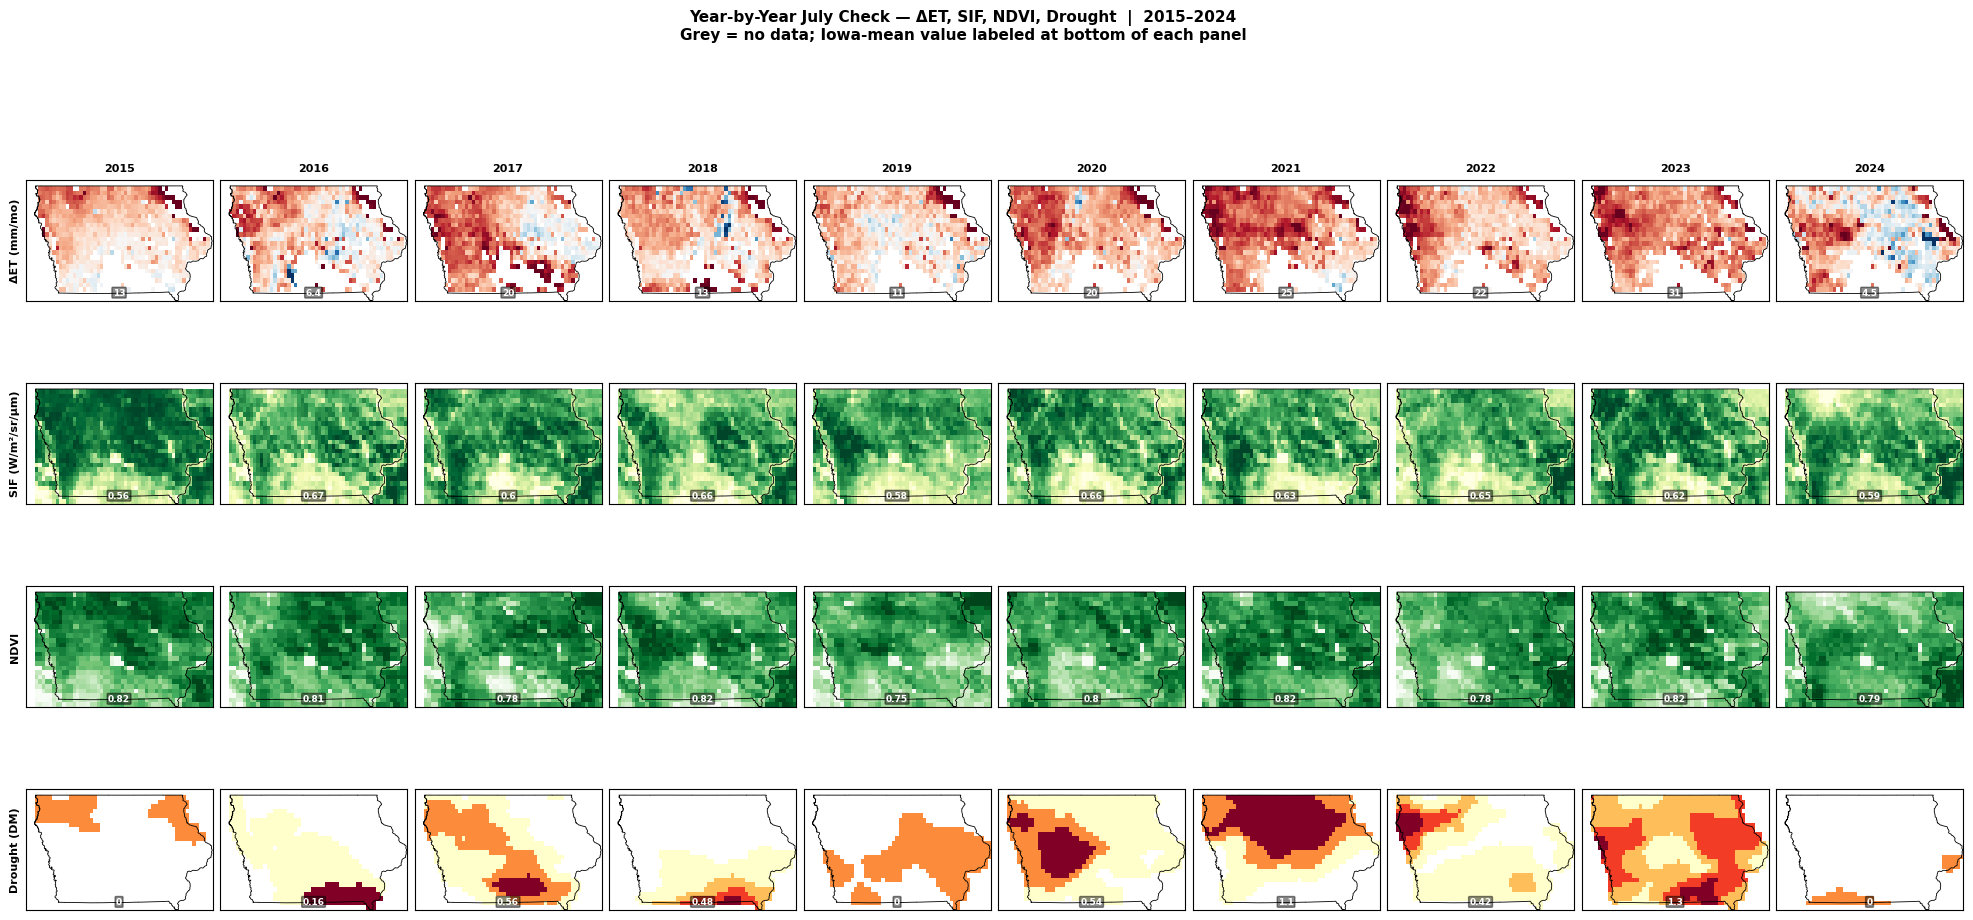

Saved: /home/pielab-sandbox-jcoldiron/SIF-Analysis/figures/sif_irr_drought/year_by_year_july_all_vars.png


In [25]:
# =============================================================================
# 4.1  Year-by-Year July Check — ΔET, SIF, NDVI, Drought (2015–2024)
# Verifies that all four data cubes are populated for each year.
# Grey panel = no data (file missing or download incomplete).
# Iowa-mean value is printed at the bottom of each panel.
# Change CHECK_MONTH to spot-check any other month.
# =============================================================================

CHECK_MONTH = 7   # July — peak growing season

var_labels = ["ΔET (mm/mo)", "SIF (W/m²/sr/μm)", "NDVI", "Drought (DM)"]
cubes_list = [et_cube, sif_cube, ndvi_cube, drought_cube]
cmaps_list = ["RdBu_r", "YlGn", "Greens", "YlOrRd"]
diverging  = [True, False, False, False]   # ΔET: symmetric around 0

# Spatial extent for imshow: [west, east, south, north]
ext = [iowa_lons[0] - 0.0625, iowa_lons[-1] + 0.0625,
       iowa_lats[-1] - 0.0625, iowa_lats[0]  + 0.0625]

n_years = len(YEARS)
n_vars  = len(var_labels)

fig, axes = plt.subplots(n_vars, n_years,
                          figsize=(n_years * 2.5, n_vars * 2.6),
                          gridspec_kw={"hspace": 0.06, "wspace": 0.04})

for row, (name, cube, cmap, div) in enumerate(zip(var_labels, cubes_list, cmaps_list, diverging)):
    for col, year in enumerate(YEARS):
        ax  = axes[row, col]
        idx = YEARS.index(year) * len(MONTHS) + (CHECK_MONTH - 1)
        arr = cube[idx].copy().astype(float)

        valid = arr[~np.isnan(arr)]
        if len(valid) == 0:
            ax.set_facecolor("#e0e0e0")
            ax.text(0.5, 0.5, "NO DATA", transform=ax.transAxes,
                    ha="center", va="center", fontsize=6.5, color="#555")
        else:
            vmin_v, vmax_v = np.nanpercentile(valid, [2, 98])
            if div:
                lim = max(abs(vmin_v), abs(vmax_v), 1.0)
                vmin_v, vmax_v = -lim, lim
            elif vmax_v - vmin_v < 1e-5:
                vmin_v -= 0.1; vmax_v += 0.1
            ax.imshow(arr, extent=ext, origin="upper",
                      cmap=cmap, vmin=vmin_v, vmax=vmax_v, aspect="auto")
            iowa_gdf.boundary.plot(ax=ax, color="black", linewidth=0.6)
            mean_val = np.nanmean(arr)
            ax.text(0.5, 0.03, f"{mean_val:.2g}", transform=ax.transAxes,
                    ha="center", va="bottom", fontsize=6.5, color="white", fontweight="bold",
                    bbox=dict(boxstyle="round,pad=0.1", fc="black", alpha=0.45))

        ax.set_xticks([]); ax.set_yticks([])
        if col == 0:
            ax.set_ylabel(name, fontsize=8, fontweight="bold")
        if row == 0:
            ax.set_title(str(year), fontsize=8, fontweight="bold")

plt.suptitle(
    f"Year-by-Year July Check — ΔET, SIF, NDVI, Drought  |  {YEARS[0]}–{YEARS[-1]}\n"
    f"Grey = no data; Iowa-mean value labeled at bottom of each panel",
    fontsize=11, fontweight="bold", y=1.01)
fig.savefig(figures_dir / "year_by_year_july_all_vars.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"Saved: {figures_dir}/year_by_year_july_all_vars.png")

## 5. Compute Pixel-Level Z-Scores

For each pixel and each calendar month, z-score across the 10 available years:

$$z(year, month, pixel) = \frac{value - \mu_{month}}{\sigma_{month}}$$

where $\mu_{month}$ and $\sigma_{month}$ are computed across all years for that calendar month.

**Why z-score?** This removes the seasonal cycle so anomalies in different months can be
compared on the same scale. A SIF z-score of +1 means plant productivity was 1 standard
deviation above the 10-year average for that month — whether it was June or September.

Z-scores are computed for both SIF and ΔET, enabling relative comparisons independent
of absolute magnitude.

In [26]:
sif_z_cube  = np.full_like(sif_cube, np.nan)
ndvi_z_cube = np.full_like(ndvi_cube, np.nan)
et_z_cube   = np.full_like(et_cube,  np.nan)

for m in range(1, 13):
    # Indices in the time axis that belong to this calendar month
    m_idx = [row['i'] for _, row in time_df.iterrows() if row['month'] == m]

    # Slice all years for this calendar month: shape (n_years, rows, cols)
    sif_slice  = sif_cube[m_idx]
    ndvi_slice = ndvi_cube[m_idx]
    et_slice   = et_cube[m_idx]

    # Compute mean and std across years (nanmean/nanstd ignore missing data)
    with np.errstate(invalid='ignore', divide='ignore'):
        sif_mean  = np.nanmean(sif_slice,  axis=0)
        sif_std   = np.nanstd( sif_slice,  axis=0, ddof=1)
        ndvi_mean = np.nanmean(ndvi_slice, axis=0)
        ndvi_std  = np.nanstd( ndvi_slice, axis=0, ddof=1)
        et_mean   = np.nanmean(et_slice,   axis=0)
        et_std    = np.nanstd( et_slice,   axis=0, ddof=1)

    # Apply z-score to each year's slice for this month
    for _, global_i in zip(range(len(m_idx)), m_idx):
        with np.errstate(invalid='ignore', divide='ignore'):
            sif_z_cube[global_i]  = (sif_cube[global_i]  - sif_mean)  / sif_std
            ndvi_z_cube[global_i] = (ndvi_cube[global_i] - ndvi_mean) / ndvi_std
            et_z_cube[global_i]   = (et_cube[global_i]   - et_mean)   / et_std

print('Z-scores computed for SIF, NDVI, and ΔET.')
print(f'  SIF-z :    {np.nanmin(sif_z_cube):.2f} to {np.nanmax(sif_z_cube):.2f}')
print(f'  NDVI-z:    {np.nanmin(ndvi_z_cube):.2f} to {np.nanmax(ndvi_z_cube):.2f}')
print(f'  ΔET-z:     {np.nanmin(et_z_cube):.2f}  to {np.nanmax(et_z_cube):.2f}')

Z-scores computed for SIF, NDVI, and ΔET.
  SIF-z :    -2.78 to 2.71
  NDVI-z:    -2.84 to 2.81
  ΔET-z:     -2.75  to 2.77


## 6. Build Analysis DataFrame

Flatten the 3-D cubes into a tidy long-format DataFrame — one row per (month, pixel).
Then filter to:
- **Growing season** (April–October) only — winter months have near-zero SIF/NDVI
- **Cropland pixels** with valid (non-NaN) ΔET, SIF, and drought data

Also assign the **irrigation group** based on the 20 mm/month threshold:
- `"High-confidence irrigation"` → ΔET > 20 mm/month
- `"Low-confidence / no irrigation"` → ΔET ≤ 20 mm/month

In [27]:
rows = []

for _, trow in time_df.iterrows():
    i     = int(trow['i'])
    year  = int(trow['year'])
    month = int(trow['month'])
    crop  = mask_cube[i]
    if not crop.any():
        continue

    rows.append(pd.DataFrame({
        'year':    year,
        'month':   month,
        'yyyymm':  trow['yyyymm'],
        'et':      et_cube[i][crop],
        'sif':     sif_cube[i][crop],
        'ndvi':    ndvi_cube[i][crop],
        'drought': drought_cube[i][crop],
        'sif_z':   sif_z_cube[i][crop],
        'ndvi_z':  ndvi_z_cube[i][crop],
        'et_z':    et_z_cube[i][crop],
    }))

df = pd.concat(rows, ignore_index=True)

# ── Growing-season filter and clean ──────────────────────────────────────────
df_gs = df[df['month'].isin(GROWING_SEASON)].copy()

# Filter to rows with valid ET, SIF, and drought (NDVI allowed to be missing)
df_gs_clean = df_gs.dropna(subset=['et', 'sif', 'drought']).copy()
df_gs_clean['dm_cat'] = df_gs_clean['drought'].astype(int)

# ── Assign irrigation group using the 20 mm/month threshold ──────────────────
# This replaces the old median split. The 20 mm/month threshold reflects the
# measurement uncertainty of the two ET products. Any ΔET above this is
# considered a high-confidence human water addition (irrigation).
df_gs_clean['irr_group'] = np.where(
    df_gs_clean['et'] > IRR_THRESHOLD_MM,
    'High-confidence irrigation',
    'Low-confidence / no irrigation'
)

# Same filter with NDVI (separate df to preserve SIF sample sizes)
df_gs_ndvi = df_gs.dropna(subset=['et', 'ndvi', 'drought']).copy()
df_gs_ndvi['dm_cat'] = df_gs_ndvi['drought'].astype(int)
df_gs_ndvi['irr_group'] = np.where(
    df_gs_ndvi['et'] > IRR_THRESHOLD_MM,
    'High-confidence irrigation',
    'Low-confidence / no irrigation'
)

print(f'Total cropland pixel-months:              {len(df):,}')
print(f'Growing-season (Apr-Oct) after SIF clean: {len(df_gs_clean):,}')
print(f'Growing-season (Apr-Oct) after NDVI clean:{len(df_gs_ndvi):,}')

pct_high = 100 * (df_gs_clean['irr_group'] == 'High-confidence irrigation').mean()
pct_low  = 100 - pct_high
print(f'\nIrrigation groups (SIF dataset, ΔET threshold = {IRR_THRESHOLD_MM} mm/month):')
print(f'  High-confidence irrigation:     {pct_high:.1f}%')
print(f'  Low-confidence / no irrigation: {pct_low:.1f}%')

print('\nDrought category counts (SIF dataset):')
for c, n in df_gs_clean['dm_cat'].value_counts().sort_index().items():
    print(f'  {c} ({DM_LABELS[c]}): {n:,}')

Total cropland pixel-months:              94,644
Growing-season (Apr-Oct) after SIF clean: 28,658
Growing-season (Apr-Oct) after NDVI clean:29,289

Irrigation groups (SIF dataset, ΔET threshold = 20.0 mm/month):
  High-confidence irrigation:     35.0%
  Low-confidence / no irrigation: 65.0%

Drought category counts (SIF dataset):
  0 (None): 15,150
  1 (D0
Abn.Dry): 6,778
  2 (D1
Moderate): 5,625
  3 (D2
Severe): 1,049
  4 (D3+
Extreme): 56


## 7. Z-Score Time Series with Drought Overlay

Three-panel time series showing growing-season monthly anomalies for Iowa cropland:
1. **SIF z-score** — plant productivity relative to the 10-year average for each calendar month
2. **ΔET z-score** — irrigation anomaly (positive = more irrigation than average, negative = less)
3. **Mean drought severity** — USDM category averaged across Iowa cropland pixels

This panel view links the three signals in time. Look for:
- SIF dropping and drought rising simultaneously (drought suppression of productivity)
- ΔET rising when drought is elevated (reactive irrigation pumping)
- Years where high ΔET coincides with maintained SIF despite drought (irrigation buffering)

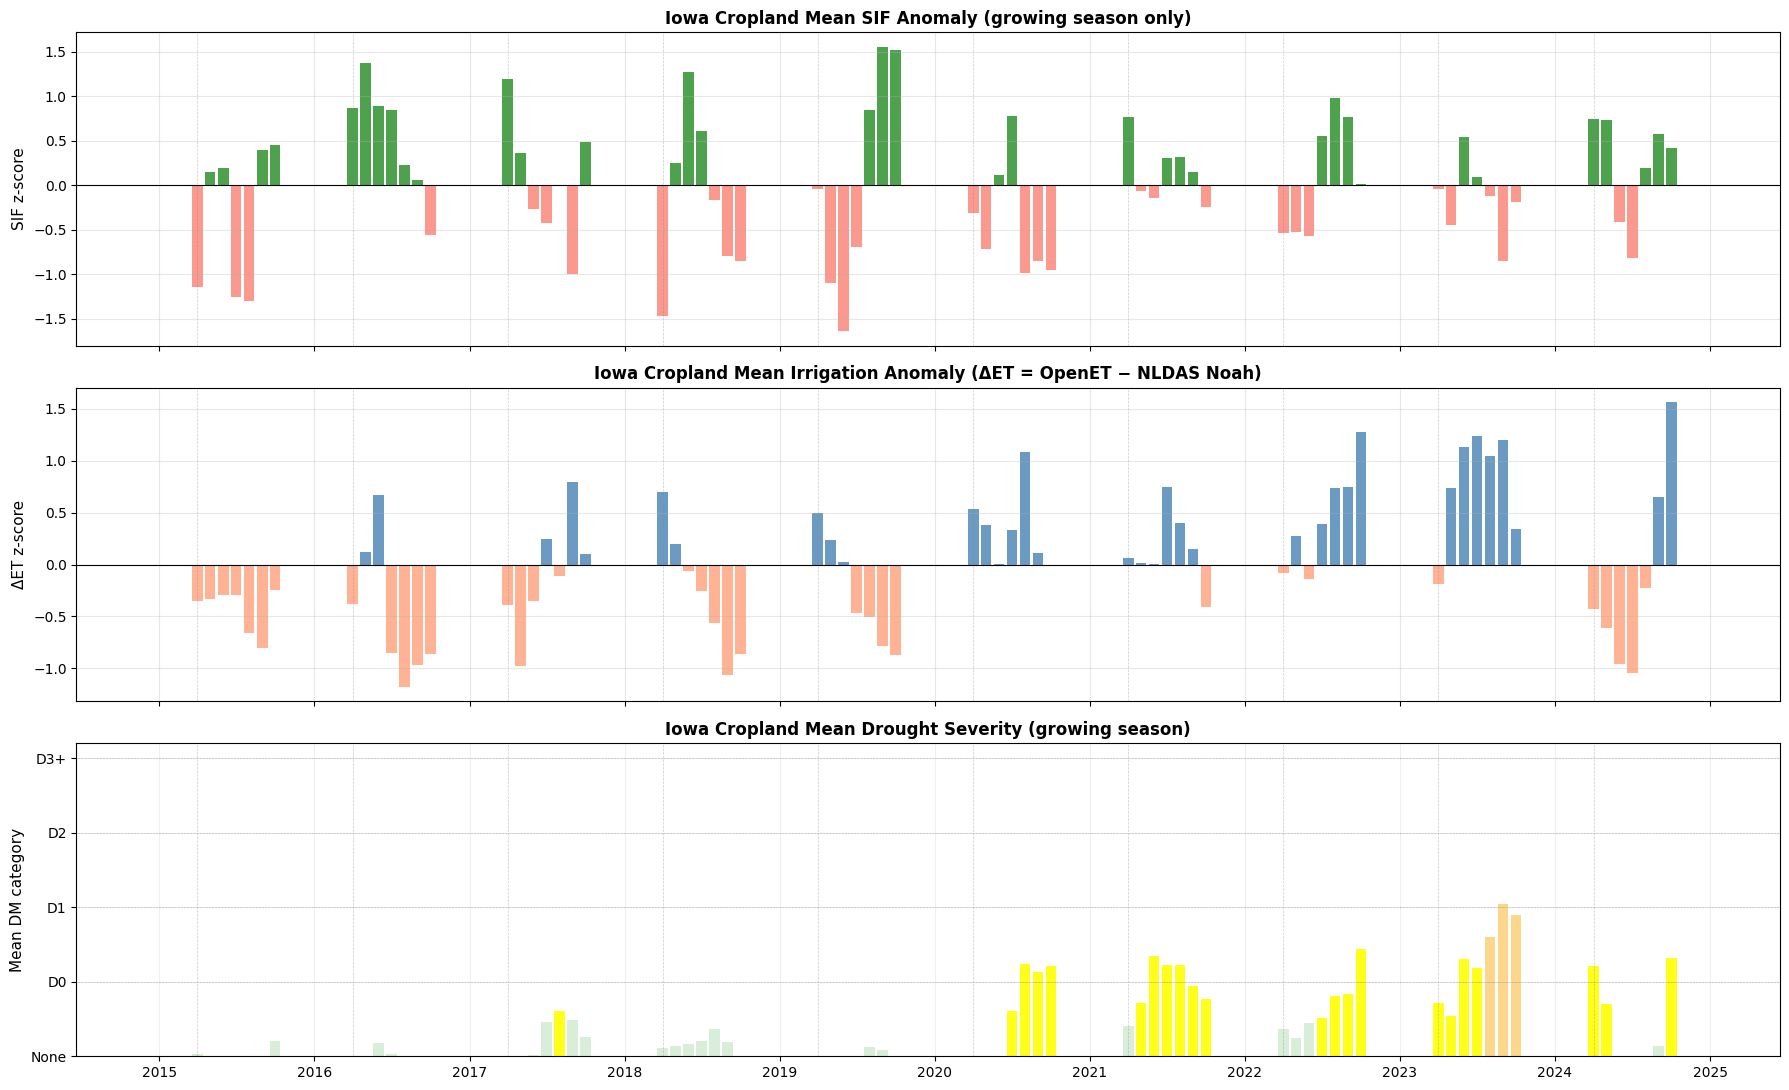

Saved: /home/pielab-sandbox-jcoldiron/SIF-Analysis/figures/sif_irr_drought/zscore_timeseries.png


In [28]:
# Iowa-wide spatial mean of z-scores per month (growing season only)
ts_rows = []
for _, trow in time_df.iterrows():
    i     = int(trow['i'])
    month = int(trow['month'])
    crop  = mask_cube[i]
    in_gs = month in GROWING_SEASON
    ts_rows.append({
        'year':    int(trow['year']),
        'month':   month,
        'yyyymm':  trow['yyyymm'],
        # Only compute spatial means during the growing season; winter is NaN
        'sif_z':   float(np.nanmean(sif_z_cube[i][crop]))  if (crop.any() and in_gs) else np.nan,
        'et_z':    float(np.nanmean(et_z_cube[i][crop]))   if (crop.any() and in_gs) else np.nan,
        'dm_mean': float(np.nanmean(drought_cube[i][crop])) if (crop.any() and in_gs) else np.nan,
    })

ts_df = pd.DataFrame(ts_rows)
ts_df['date'] = pd.to_datetime(ts_df['yyyymm'], format='%Y%m')

fig, axes = plt.subplots(3, 1, figsize=(18, 11), sharex=True)

# ── Panel 1: SIF z-score ──────────────────────────────────────────────────────
ax = axes[0]
colors = ['forestgreen' if v >= 0 else 'salmon' for v in ts_df['sif_z'].fillna(0)]
ax.bar(ts_df['date'], ts_df['sif_z'], width=25, color=colors, alpha=0.8)
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('SIF z-score', fontsize=11)
ax.set_title('Iowa Cropland Mean SIF Anomaly (growing season only)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# ── Panel 2: ΔET z-score ──────────────────────────────────────────────────────
ax = axes[1]
colors = ['steelblue' if v >= 0 else 'lightsalmon' for v in ts_df['et_z'].fillna(0)]
ax.bar(ts_df['date'], ts_df['et_z'], width=25, color=colors, alpha=0.8)
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('ΔET z-score', fontsize=11)
ax.set_title('Iowa Cropland Mean Irrigation Anomaly (ΔET = OpenET − NLDAS Noah)',
             fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# ── Panel 3: Mean drought severity ────────────────────────────────────────────
ax = axes[2]
dm_bar_colors = [
    DM_COLORS.get(int(round(v)), '#aaaaaa') if not np.isnan(v) else '#eeeeee'
    for v in ts_df['dm_mean']
]
ax.bar(ts_df['date'], ts_df['dm_mean'].fillna(0), width=25, color=dm_bar_colors, alpha=0.9)
for cat in range(5):
    ax.axhline(cat, color='gray', lw=0.4, linestyle=':')
ax.set_yticks([0, 1, 2, 3, 4])
ax.set_yticklabels(['None', 'D0', 'D1', 'D2', 'D3+'])
ax.set_ylabel('Mean DM category', fontsize=11)
ax.set_title('Iowa Cropland Mean Drought Severity (growing season)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.2)

# Add vertical year dividers to all panels
for year in YEARS:
    for a in axes:
        a.axvline(pd.Timestamp(f'{year}-04-01'), color='gray', lw=0.5, ls='--', alpha=0.4)

plt.tight_layout()
plt.savefig(figures_dir / 'zscore_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {figures_dir}/zscore_timeseries.png')

## 8. Violin Plots — SIF and ΔET Distributions by Drought Category

Growing season, cropland pixels only. Each violin shows the full distribution of z-score
values across all pixel-months in that drought category. The wide distribution in each
violin reflects the spatial heterogeneity of Iowa's cropland.

**Reading the plot:**
- SIF z-score shifting negative with increasing drought → expected drought suppression
- ΔET z-score shifting positive with drought → reactive irrigation pumping
- Wide overlapping distributions → large within-category variability from irrigation heterogeneity

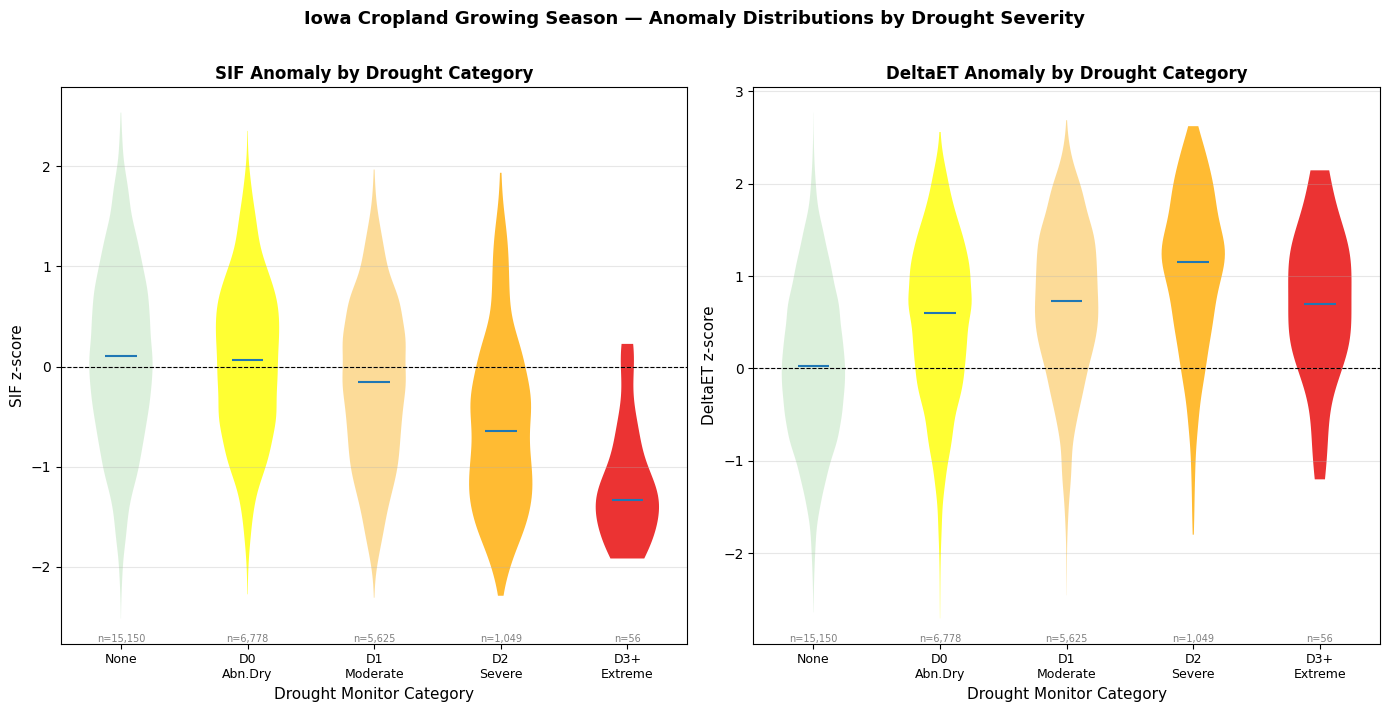

Saved: /home/pielab-sandbox-jcoldiron/SIF-Analysis/figures/sif_irr_drought/violin_by_drought.png


In [29]:
present_cats = sorted(df_gs_clean['dm_cat'].unique())
cat_labels   = [DM_LABELS[c] for c in present_cats]
cat_colors   = [DM_COLORS[c] for c in present_cats]

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

for ax, var, title, ylabel in [
    (axes[0], 'sif_z', 'SIF Anomaly by Drought Category',  'SIF z-score'),
    (axes[1], 'et_z',  'DeltaET Anomaly by Drought Category', 'DeltaET z-score'),
]:
    data_by_cat = [df_gs_clean.loc[df_gs_clean['dm_cat'] == c, var].dropna().values
                   for c in present_cats]

    if HAS_SEABORN:
        plot_df = df_gs_clean[['dm_cat', var]].dropna().copy()
        sns.violinplot(
            data=plot_df, x='dm_cat', y=var, ax=ax,
            order=present_cats,
            palette={c: DM_COLORS[c] for c in present_cats},
            inner='box', linewidth=1.2, cut=1,
        )
    else:
        parts = ax.violinplot(data_by_cat, positions=present_cats,
                              showmedians=True, showextrema=False)
        for pc, col in zip(parts['bodies'], cat_colors):
            pc.set_facecolor(col)
            pc.set_alpha(0.8)

    ax.axhline(0, color='black', lw=0.8, ls='--')
    ax.set_xticks(present_cats)
    ax.set_xticklabels(cat_labels, fontsize=9)
    ax.set_xlabel('Drought Monitor Category', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

    # Sample size annotation
    ymin = ax.get_ylim()[0]
    for c in present_cats:
        n = int((df_gs_clean['dm_cat'] == c).sum())
        ax.annotate(f'n={n:,}', xy=(c, ymin), ha='center', va='bottom', fontsize=7, color='gray')

plt.suptitle('Iowa Cropland Growing Season — Anomaly Distributions by Drought Severity',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(figures_dir / 'violin_by_drought.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {figures_dir}/violin_by_drought.png')

## 9. Does Irrigation Decouple SIF from Drought?

Split cropland pixels into two groups based on the **20 mm/month irrigation threshold**:
- **High-confidence irrigation** (ΔET > 20 mm/month) — excess ET clearly exceeds the
  combined measurement uncertainty of OpenET and NLDAS Noah, indicating real human water addition.
- **Low-confidence / no irrigation** (ΔET ≤ 20 mm/month) — signal is within noise.

Then compare how mean SIF changes across drought categories for each group.

**Expected result:** Low-confidence pixels should show classic drought suppression of SIF.
High-confidence irrigation pixels should maintain elevated SIF through moderate drought, with
suppression only occurring under severe/extreme drought conditions that irrigation cannot
fully compensate for.

High-confidence irrigation (ΔET > 20.0 mm/month): 10,044 pixel-months
Low-confidence / no irrigation:                               18,614 pixel-months


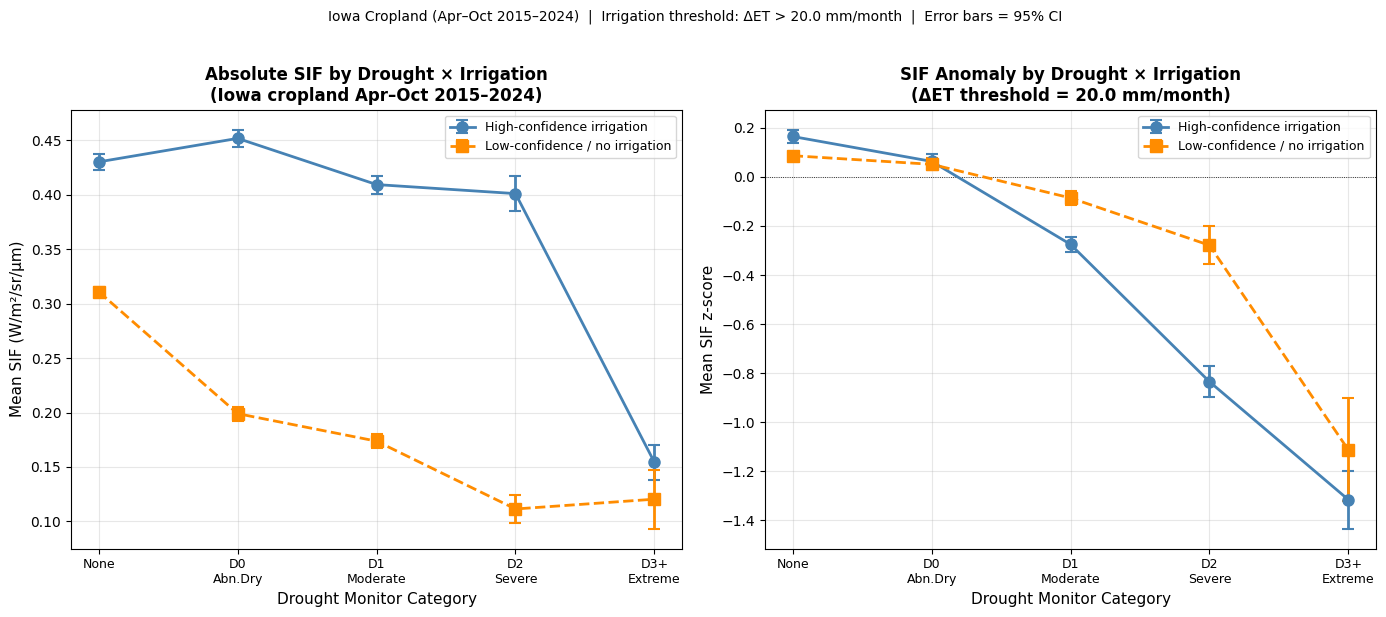

Saved: /home/pielab-sandbox-jcoldiron/SIF-Analysis/figures/sif_irr_drought/sif_by_drought_x_irrigation.png


In [30]:
# Irrigation group was already assigned in Section 6 using the 20 mm/month threshold.
# Report the group breakdown for context.
n_high = (df_gs_clean['irr_group'] == 'High-confidence irrigation').sum()
n_low  = (df_gs_clean['irr_group'] == 'Low-confidence / no irrigation').sum()
print(f'High-confidence irrigation (ΔET > {IRR_THRESHOLD_MM} mm/month): {n_high:,} pixel-months')
print(f'Low-confidence / no irrigation:                               {n_low:,} pixel-months')

present_cats = sorted(df_gs_clean['dm_cat'].unique())
cat_labels   = [DM_LABELS[c] for c in present_cats]

# Compute mean SIF and mean SIF-z per [irrigation group × drought category]
summary_sif  = (df_gs_clean.groupby(['irr_group', 'dm_cat'])['sif']
                .agg(['mean', 'sem', 'count']).reset_index())
summary_sifz = (df_gs_clean.groupby(['irr_group', 'dm_cat'])['sif_z']
                .agg(['mean', 'sem', 'count']).reset_index())

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

group_styles = {
    'High-confidence irrigation':    {'color': 'steelblue', 'marker': 'o', 'ls': '-'},
    'Low-confidence / no irrigation': {'color': 'darkorange', 'marker': 's', 'ls': '--'},
}

for ax, smry, ylabel, title in [
    (axes[0], summary_sif,  'Mean SIF (W/m²/sr/µm)',
     f'Absolute SIF by Drought × Irrigation\n(Iowa cropland Apr–Oct {YEARS[0]}–{YEARS[-1]})'),
    (axes[1], summary_sifz, 'Mean SIF z-score',
     f'SIF Anomaly by Drought × Irrigation\n(ΔET threshold = {IRR_THRESHOLD_MM} mm/month)'),
]:
    for group, style in group_styles.items():
        sub = smry[smry['irr_group'] == group].sort_values('dm_cat')
        if sub.empty:
            continue
        ax.errorbar(
            sub['dm_cat'], sub['mean'],
            yerr=1.96 * sub['sem'],
            label=group,
            color=style['color'], marker=style['marker'],
            linestyle=style['ls'], linewidth=2, markersize=8,
            capsize=4, capthick=1.5,
        )

    ax.set_xticks(present_cats)
    ax.set_xticklabels(cat_labels, fontsize=9)
    ax.set_xlabel('Drought Monitor Category', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    if 'z-score' in ylabel:
        ax.axhline(0, color='black', lw=0.6, ls=':')

plt.suptitle(
    f'Iowa Cropland (Apr–Oct {YEARS[0]}–{YEARS[-1]})  |  '
    f'Irrigation threshold: ΔET > {IRR_THRESHOLD_MM} mm/month  |  Error bars = 95% CI',
    fontsize=10, y=1.02
)
plt.tight_layout()
plt.savefig(figures_dir / 'sif_by_drought_x_irrigation.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {figures_dir}/sif_by_drought_x_irrigation.png')

## 10. SIF × ΔET Scatter Colored by Drought

Each point = one (pixel, month) growing-season observation. Color = USDM drought category.

**What to look for:** High-ΔET (irrigated) pixels maintaining high SIF even under drought
(orange/red points on the right side of the x-axis should still cluster near the top of the
y-axis). The decoupling of SIF from drought by irrigation would appear as a positive SIF
value even at high ΔET during drought conditions.

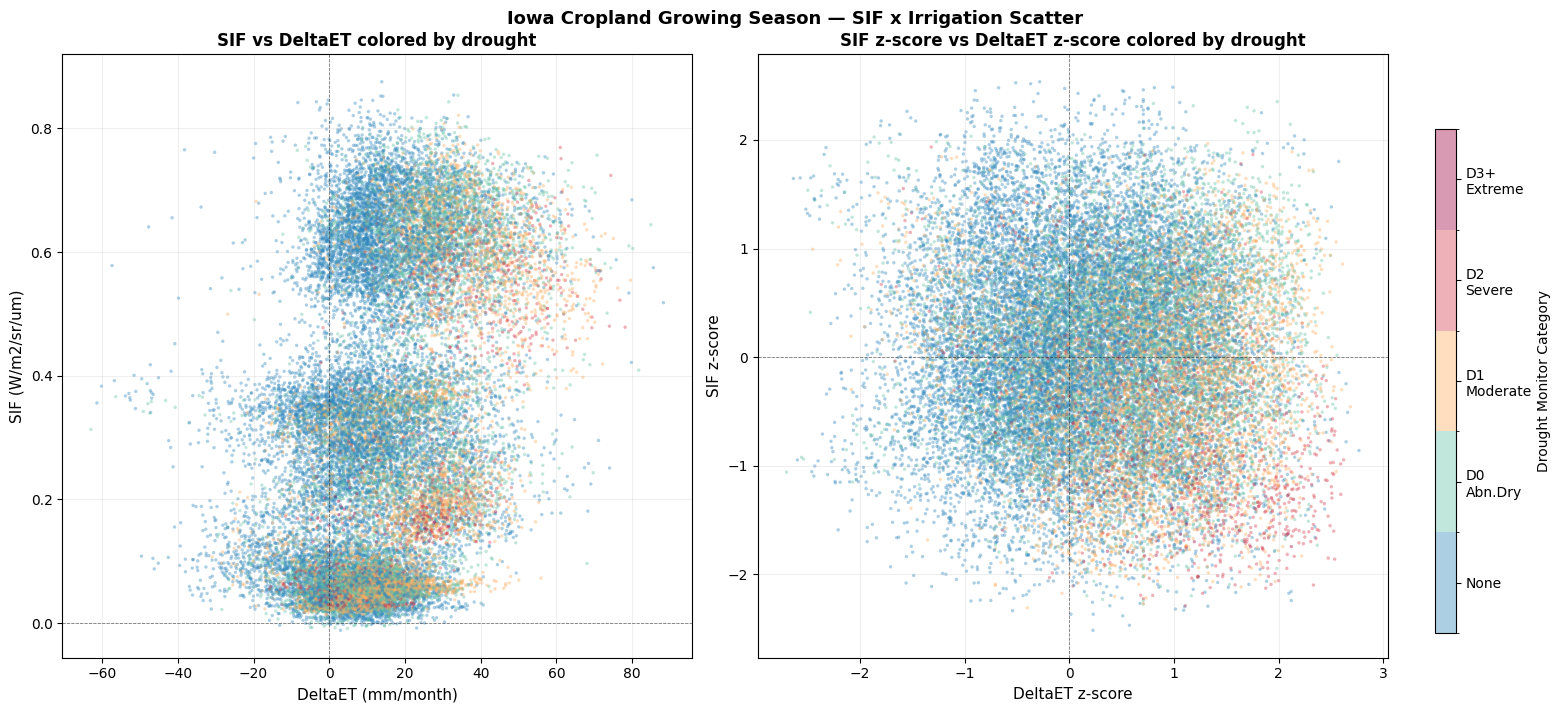

Saved: /home/pielab-sandbox-jcoldiron/SIF-Analysis/figures/sif_irr_drought/sif_irr_scatter.png


In [31]:
# Subsample if large (keeps rendering fast)
plot_df = df_gs_clean.copy()
if len(plot_df) > 50_000:
    plot_df = plot_df.sample(50_000, random_state=42)
    print(f'Subsampled to 50,000 points for plotting.')

# Spectral-derived 5-class palette — blue→teal→orange→red→deep crimson
# More saturated and perceptually distinct than the USDM pastels at small alpha
scatter_dm_colors = ['#3288BD', '#66C2A5', '#FDAE61', '#D53E4F', '#9E0142']
dm_cmap = mcolors.ListedColormap(scatter_dm_colors)
dm_norm = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5], len(scatter_dm_colors))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, xcol, ycol, xlabel, ylabel, title in [
    (axes[0], 'et',   'sif',   'DeltaET (mm/month)',  'SIF (W/m2/sr/um)',
     'SIF vs DeltaET colored by drought'),
    (axes[1], 'et_z', 'sif_z', 'DeltaET z-score', 'SIF z-score',
     'SIF z-score vs DeltaET z-score colored by drought'),
]:
    sub = plot_df.dropna(subset=[xcol, ycol, 'dm_cat'])
    sc = ax.scatter(
        sub[xcol], sub[ycol],
        c=sub['dm_cat'], cmap=dm_cmap, norm=dm_norm,
        s=6, alpha=0.4, linewidths=0,
    )
    ax.axhline(0, color='black', lw=0.6, ls='--', alpha=0.5)
    ax.axvline(0, color='black', lw=0.6, ls='--', alpha=0.5)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.2)

# Dedicated colorbar axes outside the scatter plots — doesn't steal space from either panel
plt.tight_layout(rect=[0, 0, 0.88, 1])
cbar_ax = fig.add_axes([0.90, 0.12, 0.013, 0.72])
cbar = fig.colorbar(sc, cax=cbar_ax, ticks=[0, 1, 2, 3, 4])
cbar.set_ticklabels([DM_LABELS[k] for k in [0, 1, 2, 3, 4]])
cbar.set_label('Drought Monitor Category', fontsize=10)

plt.suptitle('Iowa Cropland Growing Season — SIF x Irrigation Scatter',
             fontsize=13, fontweight='bold', y=1.01)
plt.savefig(figures_dir / 'sif_irr_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {figures_dir}/sif_irr_scatter.png')

## 11. 2D SIF Heatmap — Irrigation Level × Drought Severity

Cross-tabulate mean SIF z-score by **ΔET quartile** (rows, irrigation proxy) ×
**drought category** (columns).

- Each cell shows mean SIF z-score ± sample count for that combination.
- Blue cells = above-average crop productivity; red cells = below-average.
- The **dashed contour** traces where mean SIF z = 0 — this is the buffering threshold
  boundary. Cells above-left of the line still benefit from irrigation; cells below-right
  have passed the point where irrigation can compensate for drought stress.

ΔET quartile edges (mm/mo): [-63.    3.8  13.3  25.5  88.3]


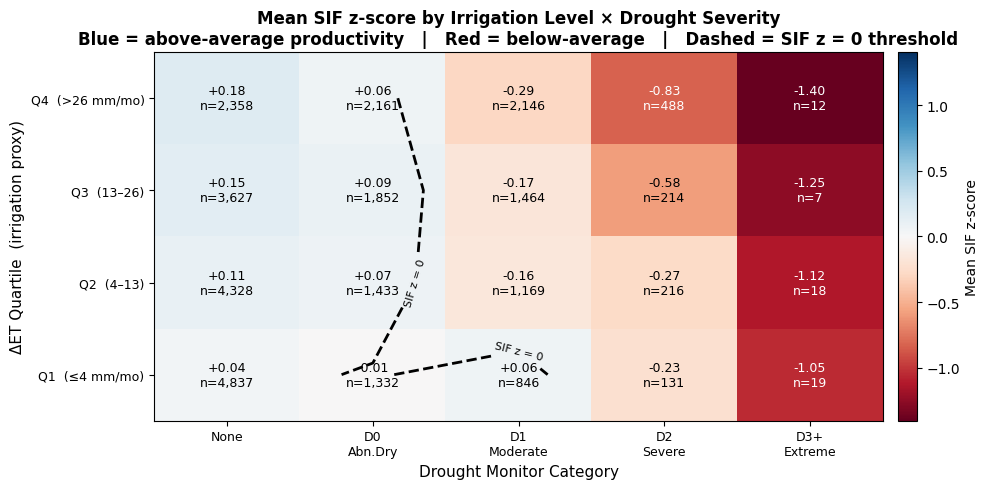

Saved: /home/pielab-sandbox-jcoldiron/SIF-Analysis/figures/sif_irr_drought/sif_heatmap_et_drought.png


In [32]:
# ΔET quartile boundaries — included in labels so axis is self-documenting
q_edges = df_gs_clean['et'].quantile([0.0, 0.25, 0.50, 0.75, 1.0]).values
et_labels = [
    f'Q1  (≤{q_edges[1]:.0f} mm/mo)',
    f'Q2  ({q_edges[1]:.0f}–{q_edges[2]:.0f})',
    f'Q3  ({q_edges[2]:.0f}–{q_edges[3]:.0f})',
    f'Q4  (>{q_edges[3]:.0f} mm/mo)',
]
print('ΔET quartile edges (mm/mo):', q_edges.round(1))

df_hm = df_gs_clean.copy()
df_hm['et_q'] = pd.qcut(df_hm['et'], q=4, labels=et_labels, duplicates='drop')

pivot_mean = (df_hm.groupby(['et_q', 'dm_cat'])['sif_z']
              .mean().unstack('dm_cat'))
pivot_n    = (df_hm.groupby(['et_q', 'dm_cat'])['sif_z']
              .count().unstack('dm_cat'))

# Q4 (most irrigation) at the top
pivot_mean = pivot_mean.iloc[::-1]
pivot_n    = pivot_n.iloc[::-1]

fig, ax = plt.subplots(figsize=(10, 5))

data = pivot_mean.values
vmax = np.nanmax(np.abs(data))
im = ax.imshow(data, cmap='RdBu', vmin=-vmax, vmax=vmax, aspect='auto')

# Annotate each cell: mean SIF z and sample count
for i in range(pivot_mean.shape[0]):
    for j in range(pivot_mean.shape[1]):
        val = data[i, j]
        n   = pivot_n.values[i, j]
        if not np.isnan(val):
            txt_col = 'white' if abs(val) > vmax * 0.55 else 'black'
            ax.text(j, i, f'{val:+.2f}\nn={int(n):,}',
                    ha='center', va='center', fontsize=9, color=txt_col)

# Dashed zero-contour marks where irrigation buffering breaks down
filled = np.where(np.isnan(data), 0.0, data)
cs = ax.contour(filled, levels=[0], colors='k', linewidths=2, linestyles='--')
ax.clabel(cs, fmt='SIF z = 0', fontsize=8, inline=True)

ax.set_xticks(range(pivot_mean.shape[1]))
ax.set_xticklabels([DM_LABELS[c] for c in pivot_mean.columns], fontsize=9)
ax.set_yticks(range(pivot_mean.shape[0]))
ax.set_yticklabels(pivot_mean.index, fontsize=9)
ax.set_xlabel('Drought Monitor Category', fontsize=11)
ax.set_ylabel('ΔET Quartile  (irrigation proxy)', fontsize=11)
ax.set_title(
    'Mean SIF z-score by Irrigation Level × Drought Severity\n'
    'Blue = above-average productivity   |   Red = below-average   |   '
    'Dashed = SIF z = 0 threshold',
    fontsize=12, fontweight='bold'
)

cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label('Mean SIF z-score', fontsize=10)

plt.tight_layout()
plt.savefig(figures_dir / 'sif_heatmap_et_drought.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {figures_dir}/sif_heatmap_et_drought.png')

## 12. Irrigation Buffering Gap Curve

**Buffering gap** = mean SIF z-score (High-confidence irrigation) −
mean SIF z-score (Low-confidence / no irrigation) at each drought level.

Shading = 95% CI on the difference (propagated from both group SEMs).

- **Positive gap** → irrigation is associated with higher-than-expected SIF relative to
  non-irrigated pixels under the same drought.
- **Gap near zero / negative** → the drought severity at which irrigation provides no
  measurable productivity benefit — the **effective buffering threshold**.

Note: With the 20 mm/month threshold instead of the old median split, the "High-confidence"
group is more specifically defined — pixels definitively receiving irrigation rather than
merely above-average ΔET.

Buffering gap by drought category:
 dm_cat       gap       ci  n_high  n_low
      0  0.078341 0.032498    3703  11447
      1  0.011914 0.038843    2903   3875
      2 -0.189323 0.041838    2838   2787
      3 -0.556311 0.099603     583    466
      4 -0.203059 0.241123      17     39


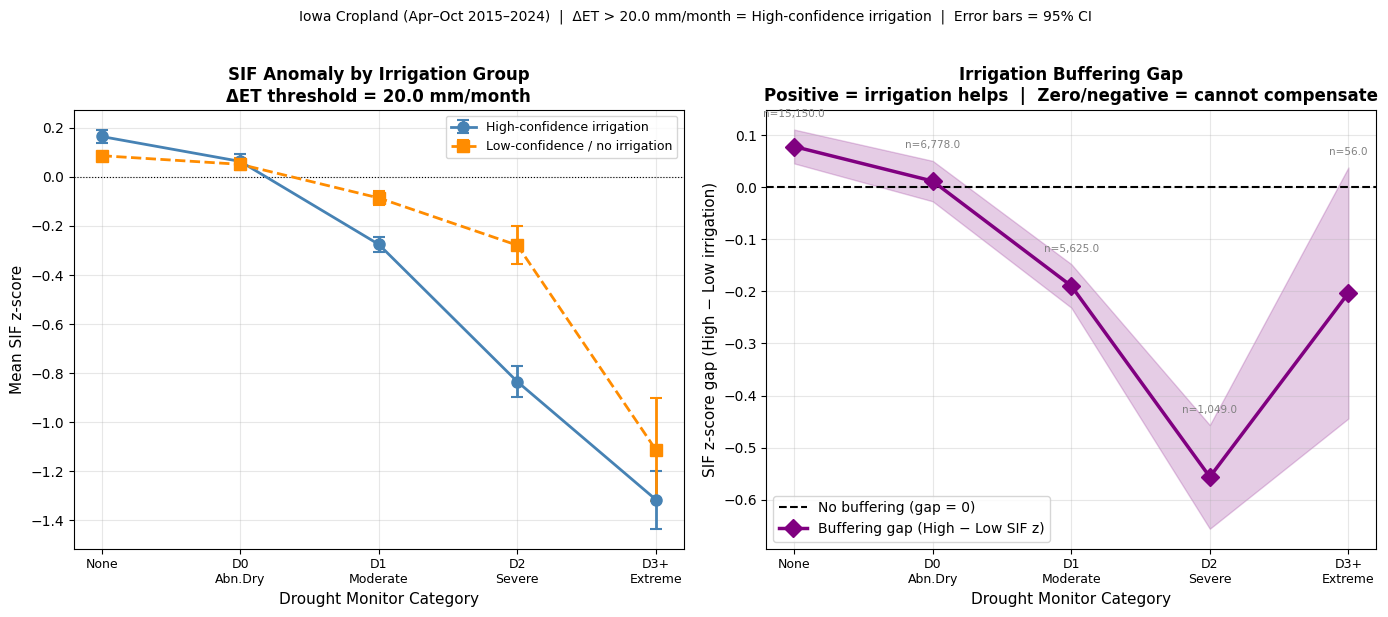

Saved: /home/pielab-sandbox-jcoldiron/SIF-Analysis/figures/sif_irr_drought/sif_buffering_gap.png


In [33]:
# Buffering gap = High-confidence irrigation SIF z − Low-confidence SIF z per drought category
stats = (df_gs_clean.groupby(['irr_group', 'dm_cat'])['sif_z']
         .agg(['mean', 'sem', 'count']).reset_index())

HIGH_GROUP = 'High-confidence irrigation'
LOW_GROUP  = 'Low-confidence / no irrigation'

gap_rows = []
for cat in present_cats:
    h = stats[(stats['irr_group'] == HIGH_GROUP) & (stats['dm_cat'] == cat)]
    l = stats[(stats['irr_group'] == LOW_GROUP)  & (stats['dm_cat'] == cat)]
    if h.empty or l.empty:
        continue
    gap    = float(h['mean'].iloc[0]) - float(l['mean'].iloc[0])
    se_gap = np.sqrt(float(h['sem'].iloc[0])**2 + float(l['sem'].iloc[0])**2)
    gap_rows.append({'dm_cat': cat, 'gap': gap, 'ci': 1.96 * se_gap,
                     'n_high': int(h['count'].iloc[0]), 'n_low': int(l['count'].iloc[0])})

gap_df = pd.DataFrame(gap_rows)
print('Buffering gap by drought category:')
print(gap_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Left panel: individual group means ────────────────────────────────────────
ax = axes[0]
for group, color, marker, ls in [
    (HIGH_GROUP, 'steelblue',  'o', '-'),
    (LOW_GROUP,  'darkorange', 's', '--'),
]:
    sub = stats[stats['irr_group'] == group].sort_values('dm_cat')
    ax.errorbar(sub['dm_cat'], sub['mean'], yerr=1.96 * sub['sem'],
                label=group, color=color, marker=marker,
                linestyle=ls, linewidth=2, markersize=8, capsize=4, capthick=1.5)

ax.axhline(0, color='black', lw=0.8, ls=':')
ax.set_xticks(present_cats)
ax.set_xticklabels(cat_labels, fontsize=9)
ax.set_xlabel('Drought Monitor Category', fontsize=11)
ax.set_ylabel('Mean SIF z-score', fontsize=11)
ax.set_title(f'SIF Anomaly by Irrigation Group\n'
             f'ΔET threshold = {IRR_THRESHOLD_MM} mm/month', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ── Right panel: buffering gap ─────────────────────────────────────────────────
ax = axes[1]
ax.axhline(0, color='black', lw=1.5, ls='--', zorder=2, label='No buffering (gap = 0)')
ax.fill_between(gap_df['dm_cat'],
                gap_df['gap'] - gap_df['ci'],
                gap_df['gap'] + gap_df['ci'],
                alpha=0.2, color='purple')
ax.plot(gap_df['dm_cat'], gap_df['gap'],
        color='purple', marker='D', linewidth=2.5, markersize=9, zorder=3,
        label='Buffering gap (High − Low SIF z)')

# Sample size annotations above each point
for _, row in gap_df.iterrows():
    ax.annotate(f"n={row['n_high']+row['n_low']:,}",
                xy=(row['dm_cat'], row['gap'] + row['ci'] + 0.02),
                ha='center', va='bottom', fontsize=7.5, color='gray')

ax.set_xticks(present_cats)
ax.set_xticklabels(cat_labels, fontsize=9)
ax.set_xlabel('Drought Monitor Category', fontsize=11)
ax.set_ylabel('SIF z-score gap (High − Low irrigation)', fontsize=11)
ax.set_title('Irrigation Buffering Gap\n'
             'Positive = irrigation helps  |  Zero/negative = cannot compensate',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.suptitle(
    f'Iowa Cropland (Apr–Oct {YEARS[0]}–{YEARS[-1]})  |  '
    f'ΔET > {IRR_THRESHOLD_MM} mm/month = High-confidence irrigation  |  Error bars = 95% CI',
    fontsize=10, y=1.02
)
plt.tight_layout()
plt.savefig(figures_dir / 'sif_buffering_gap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {figures_dir}/sif_buffering_gap.png')

## 13. NDVI Analysis — Parallel to SIF

This section repeats the core analyses from Sections 7–12 using **NDVI** (Normalized
Difference Vegetation Index from MODIS MOD13A3) instead of SIF. Structure mirrors the
SIF analysis exactly for direct comparison.

**Why compare NDVI and SIF?**
- **SIF** reflects actual photosynthetic activity — sensitive to both canopy structure
  and light use efficiency. Can detect stress even when leaves are still green.
- **NDVI** tracks canopy greenness/structure — responds mainly to leaf area and chlorophyll
  content. Less sensitive to light use efficiency changes under stress.

Comparing the two reveals whether the irrigation buffering signal is consistent across
both indicators, and where they diverge (early-season cold stress, late-season senescence).

### Figures in this section

13.2 — NDVI z-score time series with drought overlay (matches Section 7)
13.3 — NDVI violin plots by drought category (matches Section 8)
13.4 — NDVI × irrigation × drought: scatter, heatmap, buffering gap (matches Sections 9–12)

In [34]:
# ── Check NDVI availability ───────────────────────────────────────────────────
n_ndvi_avail = int((~np.isnan(ndvi_cube)).any(axis=(1, 2)).sum())
if n_ndvi_avail == 0:
    print('⚠  No NDVI data found. Run 07_download_ndvi_iowa.py first.')
    print('   Skipping Section 13 (NDVI analysis).')
else:
    print(f'NDVI data available for {n_ndvi_avail} months. Proceeding with analysis.')

# df_gs_ndvi is the full growing-season NDVI dataframe (no fallow masking).
# It is built in Section 6 alongside df_gs_clean.
if n_ndvi_avail > 0 and 'df_gs_ndvi' in dir():
    print(f'NDVI pixel-months (growing season): {len(df_gs_ndvi):,}')
    print(f'NDVI range:  min={df_gs_ndvi["ndvi"].min():.3f}  '
          f'max={df_gs_ndvi["ndvi"].max():.3f}  '
          f'mean={df_gs_ndvi["ndvi"].mean():.3f}')

NDVI data available for 120 months. Proceeding with analysis.

13.1 Fallow Detection
     Fallow threshold: NDVI < 0.3 in growing season

     Total growing-season cropland pixel-months: 29,289
     Flagged as potentially fallow (NDVI < 0.3): 2,865  (9.8%)

     Monthly fallow rate:
       Apr:  68.5% ██████████████████████████████████
       May:   8.0% ████
       Jun:   0.0% 
       Jul:   0.0% 
       Aug:   0.0% 
       Sep:   0.0% 
       Oct:   5.9% ██

     Mean NDVI by fallow status × drought:
                  mean_ndvi      n
is_fallow dm_cat                  
False     0        0.671095  13848
          1        0.653764   6353
          2        0.650385   5218
          3        0.632216    956
          4        0.579555     49
True      0        0.266436   1620
          1        0.262518    668
          2        0.265622    474
          3        0.285447     96
          4        0.252886      7

     Dataframe A (fallow masked):   26,424 pixel-months
     Dataframe 

### 13.2 NDVI Z-Score Time Series with Drought Overlay

Same three-panel layout as Section 7, but with NDVI z-score instead of SIF z-score.
Compare the two time series to see whether NDVI and SIF respond similarly to drought
and irrigation signals. Key differences to watch for:
- **SIF responds to light use efficiency** (even green plants can have low SIF under stress)
- **NDVI responds to canopy structure** (stays high as long as leaves are present, regardless of photosynthetic activity)
- Early-season divergence (April–May) may reflect different sensitivity to cold temperatures and canopy development timing

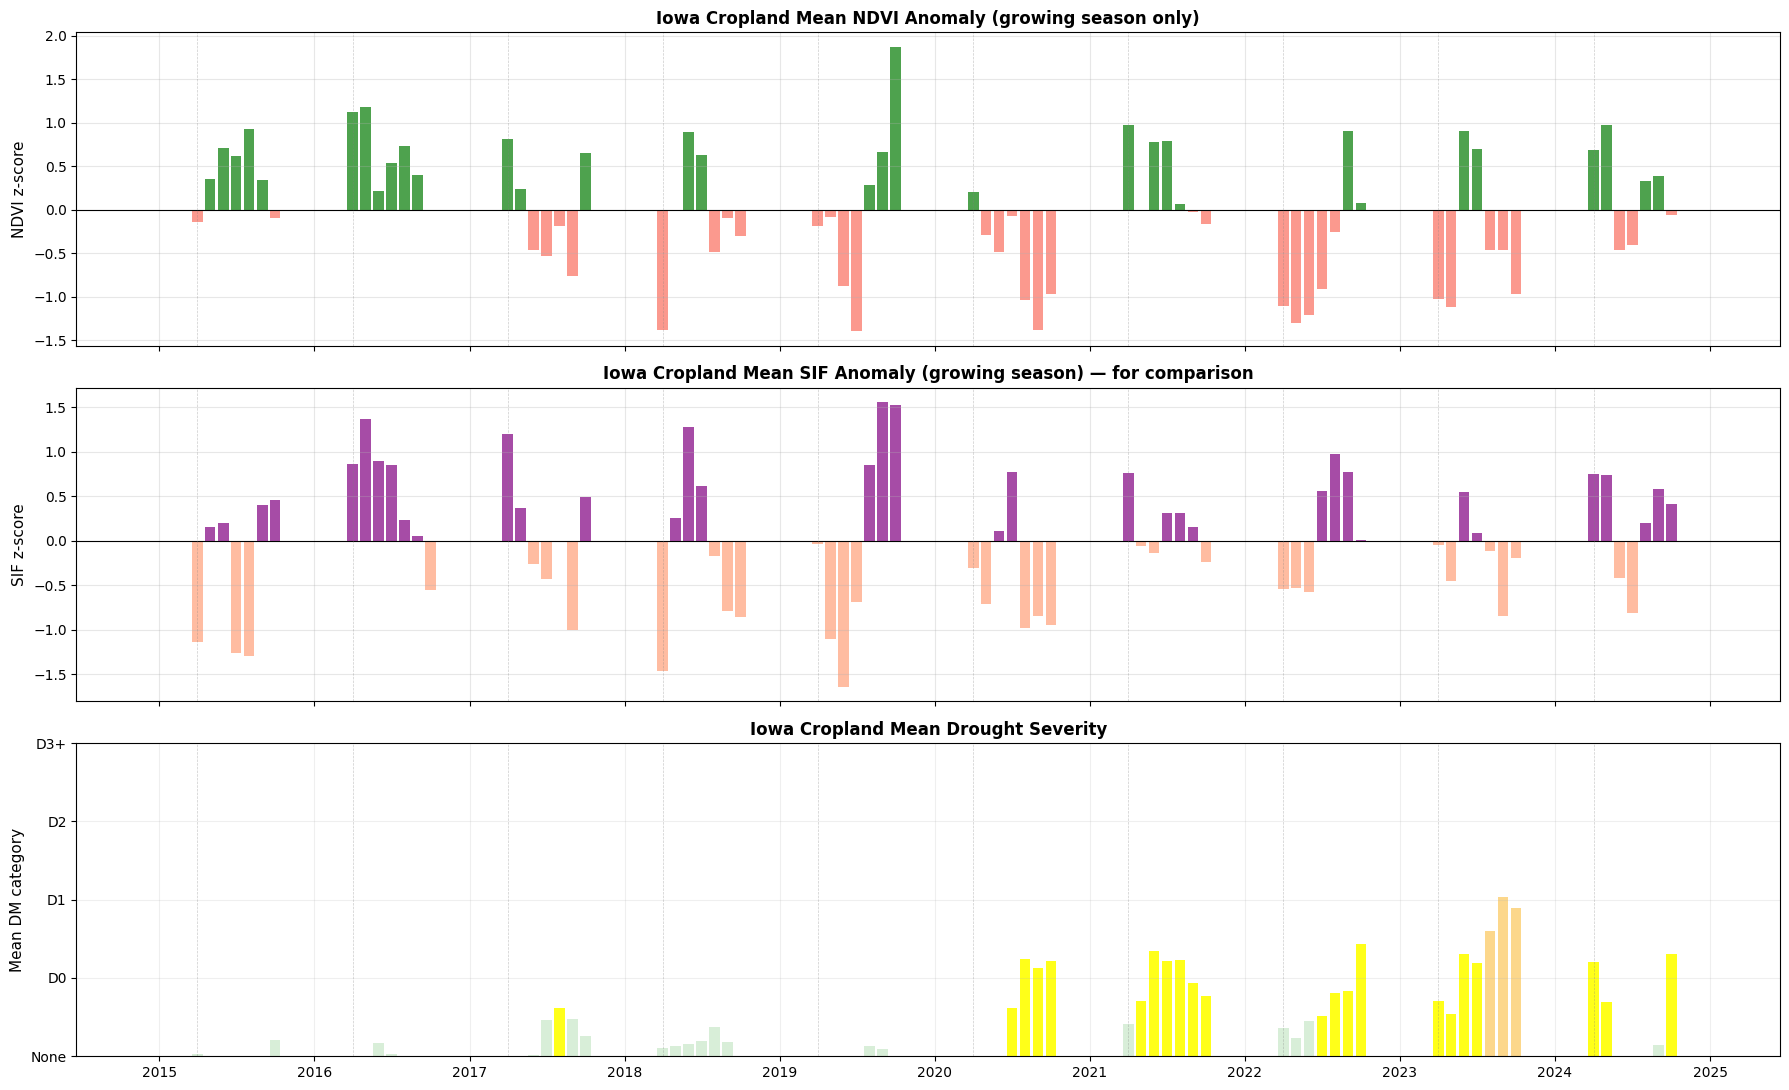

Saved: /home/pielab-sandbox-jcoldiron/SIF-Analysis/figures/sif_irr_drought/ndvi_zscore_timeseries.png


In [39]:
if n_ndvi_avail == 0:
    print('Skipping NDVI time series — no NDVI data available.')
else:
    # Compute Iowa-wide spatial mean NDVI z-score per month (growing season only)
    ndvi_ts_rows = []
    for _, trow in time_df.iterrows():
        i     = int(trow['i'])
        month = int(trow['month'])
        crop  = mask_cube[i]
        in_gs = month in GROWING_SEASON
        ndvi_ts_rows.append({
            'yyyymm':  trow['yyyymm'],
            'ndvi_z':  float(np.nanmean(ndvi_z_cube[i][crop])) if (crop.any() and in_gs) else np.nan,
            'dm_mean': float(np.nanmean(drought_cube[i][crop])) if (crop.any() and in_gs) else np.nan,
        })

    ndvi_ts_df = pd.DataFrame(ndvi_ts_rows)
    ndvi_ts_df['date'] = pd.to_datetime(ndvi_ts_df['yyyymm'], format='%Y%m')

    fig, axes = plt.subplots(3, 1, figsize=(18, 11), sharex=True)

    # ── Panel 1: NDVI z-score ─────────────────────────────────────────────────
    ax = axes[0]
    colors = ['forestgreen' if v >= 0 else 'salmon' for v in ndvi_ts_df['ndvi_z'].fillna(0)]
    ax.bar(ndvi_ts_df['date'], ndvi_ts_df['ndvi_z'], width=25, color=colors, alpha=0.8)
    ax.axhline(0, color='black', lw=0.8)
    ax.set_ylabel('NDVI z-score', fontsize=11)
    ax.set_title('Iowa Cropland Mean NDVI Anomaly (growing season only)', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

    # ── Panel 2: SIF z-score (for comparison) ────────────────────────────────
    ax = axes[1]
    colors = ['purple' if v >= 0 else 'lightsalmon' for v in ts_df['sif_z'].fillna(0)]
    ax.bar(ts_df['date'], ts_df['sif_z'], width=25, color=colors, alpha=0.7)
    ax.axhline(0, color='black', lw=0.8)
    ax.set_ylabel('SIF z-score', fontsize=11)
    ax.set_title('Iowa Cropland Mean SIF Anomaly (growing season) — for comparison',
                 fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

    # ── Panel 3: Drought ──────────────────────────────────────────────────────
    ax = axes[2]
    dm_bar_colors = [
        DM_COLORS.get(int(round(v)), '#aaaaaa') if not np.isnan(v) else '#eeeeee'
        for v in ndvi_ts_df['dm_mean']
    ]
    ax.bar(ndvi_ts_df['date'], ndvi_ts_df['dm_mean'].fillna(0),
           width=25, color=dm_bar_colors, alpha=0.9)
    ax.set_yticks([0, 1, 2, 3, 4])
    ax.set_yticklabels(['None', 'D0', 'D1', 'D2', 'D3+'])
    ax.set_ylabel('Mean DM category', fontsize=11)
    ax.set_title('Iowa Cropland Mean Drought Severity', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.2)

    for year in YEARS:
        for a in axes:
            a.axvline(pd.Timestamp(f'{year}-04-01'), color='gray', lw=0.5, ls='--', alpha=0.4)

    plt.tight_layout()
    plt.savefig(figures_dir / 'ndvi_zscore_timeseries.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {figures_dir}/ndvi_zscore_timeseries.png')

### 13.3 NDVI Violin Plots by Drought Category

Distribution of growing-season NDVI z-scores across USDM drought categories,
matching the structure of Section 8 (SIF violin plots).

**Expected:** NDVI z-scores should decrease with increasing drought severity,
but less sharply than SIF because NDVI is less sensitive to light use efficiency
reductions (leaves stay green longer under mild stress).

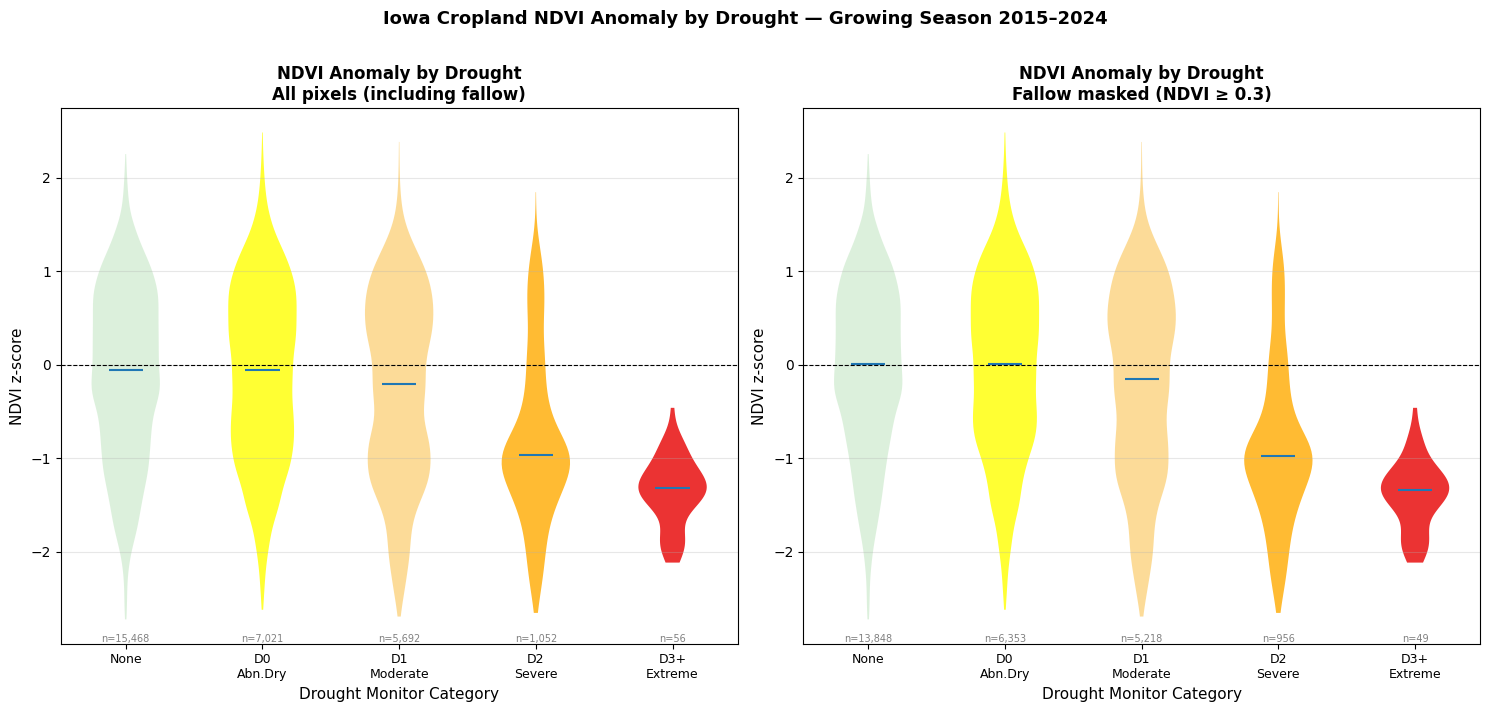

Saved: /home/pielab-sandbox-jcoldiron/SIF-Analysis/figures/sif_irr_drought/ndvi_violin_by_drought.png


In [40]:
if n_ndvi_avail == 0:
    print('Skipping NDVI violin plots — no NDVI data.')
else:
    ndvi_present_cats = sorted(df_gs_ndvi['dm_cat'].unique())
    ndvi_cat_labels   = [DM_LABELS[c] for c in ndvi_present_cats]

    fig, ax = plt.subplots(figsize=(10, 6))

    data_by_cat = [
        df_gs_ndvi.loc[df_gs_ndvi['dm_cat'] == c, 'ndvi_z'].dropna().values
        for c in ndvi_present_cats
    ]
    parts = ax.violinplot(data_by_cat, positions=ndvi_present_cats,
                          showmedians=True, showextrema=False)
    for pc, col in zip(parts['bodies'], [DM_COLORS[c] for c in ndvi_present_cats]):
        pc.set_facecolor(col)
        pc.set_alpha(0.8)

    ax.axhline(0, color='black', lw=0.8, ls='--')
    ax.set_xticks(ndvi_present_cats)
    ax.set_xticklabels(ndvi_cat_labels, fontsize=9)
    ax.set_xlabel('Drought Monitor Category', fontsize=11)
    ax.set_ylabel('NDVI z-score', fontsize=11)
    ax.set_title(
        f'Iowa Cropland NDVI Anomaly by Drought Category\n'
        f'Growing Season {YEARS[0]}–{YEARS[-1]}',
        fontsize=12, fontweight='bold'
    )
    ax.grid(True, alpha=0.3, axis='y')

    ymin = ax.get_ylim()[0]
    for c in ndvi_present_cats:
        n = int((df_gs_ndvi['dm_cat'] == c).sum())
        ax.annotate(f'n={n:,}', xy=(c, ymin), ha='center', va='bottom',
                    fontsize=7, color='gray')

    plt.tight_layout()
    plt.savefig(figures_dir / 'ndvi_violin_by_drought.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {figures_dir}/ndvi_violin_by_drought.png')

### 13.4 NDVI × Irrigation × Drought — Parallel to Sections 9–12

Repeat the core irrigation buffering analysis using NDVI z-score instead of SIF z-score.
This produces three parallel figures for direct comparison:
- `ndvi_by_drought_x_irrigation.png` ↔ `sif_by_drought_x_irrigation.png`
- `ndvi_heatmap_et_drought.png` ↔ `sif_heatmap_et_drought.png`
- `ndvi_buffering_gap.png` ↔ `sif_buffering_gap.png`

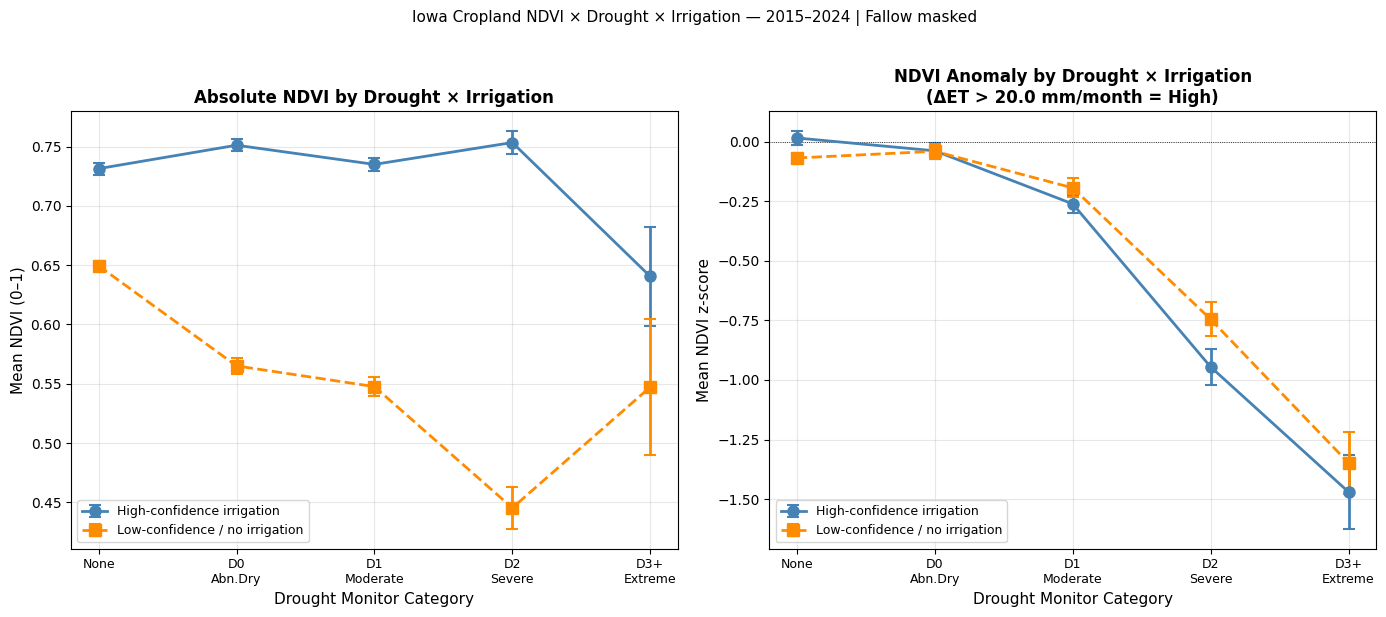

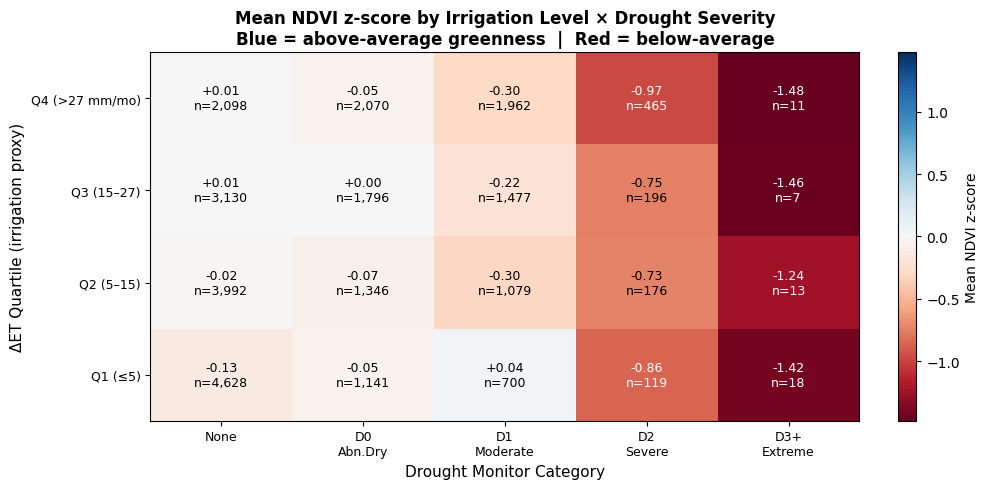

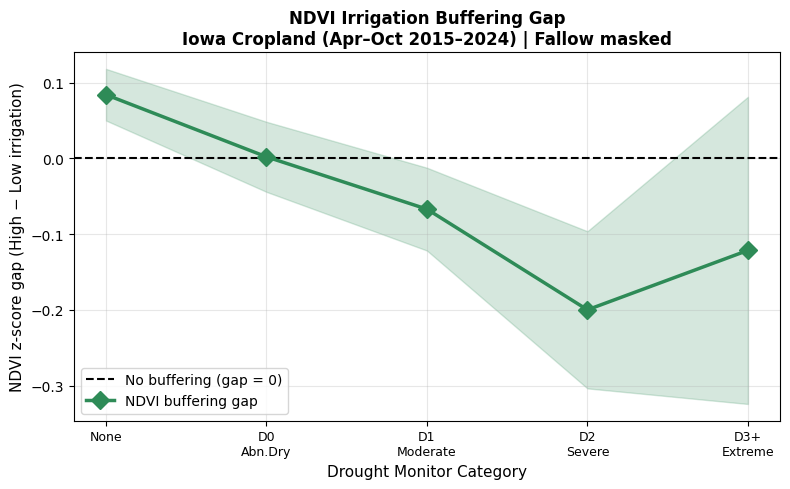

Saved: ndvi_by_drought_x_irrigation.png, ndvi_heatmap_et_drought.png, ndvi_buffering_gap.png


In [41]:
if n_ndvi_avail == 0:
    print('Skipping NDVI irrigation × drought analysis — no NDVI data.')
else:
    # Use fallow-masked dataframe for cleaner signal
    df_ndvi_irr = df_gs_ndvi.copy()
    ndvi_present_cats = sorted(df_ndvi_irr['dm_cat'].unique())
    ndvi_cat_labels   = [DM_LABELS[c] for c in ndvi_present_cats]

    # ── 13.4a NDVI by drought × irrigation group ──────────────────────────────
    ndvi_irr_summary = (
        df_ndvi_irr.groupby(['irr_group', 'dm_cat'])['ndvi_z']
        .agg(['mean', 'sem', 'count']).reset_index()
    )
    ndvi_abs_summary = (
        df_ndvi_irr.groupby(['irr_group', 'dm_cat'])['ndvi']
        .agg(['mean', 'sem', 'count']).reset_index()
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    for ax, smry, ylabel, title in [
        (axes[0], ndvi_abs_summary, 'Mean NDVI (0–1)',
         'Absolute NDVI by Drought × Irrigation'),
        (axes[1], ndvi_irr_summary, 'Mean NDVI z-score',
         f'NDVI Anomaly by Drought × Irrigation\n(ΔET > {IRR_THRESHOLD_MM} mm/month = High)'),
    ]:
        for group, style in group_styles.items():
            sub = smry[smry['irr_group'] == group].sort_values('dm_cat')
            if sub.empty: continue
            ax.errorbar(sub['dm_cat'], sub['mean'], yerr=1.96 * sub['sem'],
                        label=group, color=style['color'], marker=style['marker'],
                        linestyle=style['ls'], linewidth=2, markersize=8,
                        capsize=4, capthick=1.5)
        ax.set_xticks(ndvi_present_cats)
        ax.set_xticklabels(ndvi_cat_labels, fontsize=9)
        ax.set_xlabel('Drought Monitor Category', fontsize=11)
        ax.set_ylabel(ylabel, fontsize=11)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        if 'z-score' in ylabel:
            ax.axhline(0, color='black', lw=0.6, ls=':')

    plt.suptitle(f'Iowa Cropland NDVI × Drought × Irrigation — '
                 f'{YEARS[0]}–{YEARS[-1]} | Iowa cropland',
                 fontsize=11, y=1.02)
    plt.tight_layout()
    plt.savefig(figures_dir / 'ndvi_by_drought_x_irrigation.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ── 13.4b NDVI 2D heatmap: ΔET quartile × drought ────────────────────────
    q_edges = df_ndvi_irr['et'].quantile([0.0, 0.25, 0.50, 0.75, 1.0]).values
    et_labels = [f'Q1 (≤{q_edges[1]:.0f})',
                 f'Q2 ({q_edges[1]:.0f}–{q_edges[2]:.0f})',
                 f'Q3 ({q_edges[2]:.0f}–{q_edges[3]:.0f})',
                 f'Q4 (>{q_edges[3]:.0f} mm/mo)']

    df_ndvi_hm = df_ndvi_irr.copy()
    df_ndvi_hm['et_q'] = pd.qcut(df_ndvi_hm['et'], q=4, labels=et_labels, duplicates='drop')

    pivot_ndvi = (df_ndvi_hm.groupby(['et_q', 'dm_cat'])['ndvi_z'].mean()
                  .unstack('dm_cat').iloc[::-1])
    pivot_n    = (df_ndvi_hm.groupby(['et_q', 'dm_cat'])['ndvi_z'].count()
                  .unstack('dm_cat').iloc[::-1])

    fig, ax = plt.subplots(figsize=(10, 5))
    data = pivot_ndvi.values
    vmax = np.nanmax(np.abs(data))
    im = ax.imshow(data, cmap='RdBu', vmin=-vmax, vmax=vmax, aspect='auto')

    for i in range(pivot_ndvi.shape[0]):
        for j in range(pivot_ndvi.shape[1]):
            val = data[i, j]
            n   = pivot_n.values[i, j] if not np.isnan(data[i, j]) else 0
            if not np.isnan(val):
                txt_col = 'white' if abs(val) > vmax * 0.55 else 'black'
                ax.text(j, i, f'{val:+.2f}\nn={int(n):,}',
                        ha='center', va='center', fontsize=9, color=txt_col)

    ax.set_xticks(range(pivot_ndvi.shape[1]))
    ax.set_xticklabels([DM_LABELS[c] for c in pivot_ndvi.columns], fontsize=9)
    ax.set_yticks(range(pivot_ndvi.shape[0]))
    ax.set_yticklabels(pivot_ndvi.index, fontsize=9)
    ax.set_xlabel('Drought Monitor Category', fontsize=11)
    ax.set_ylabel('ΔET Quartile (irrigation proxy)', fontsize=11)
    ax.set_title('Mean NDVI z-score by Irrigation Level × Drought Severity\n'
                 'Blue = above-average greenness  |  Red = below-average',
                 fontsize=12, fontweight='bold')
    plt.colorbar(im, ax=ax, fraction=0.03).set_label('Mean NDVI z-score', fontsize=10)
    plt.tight_layout()
    plt.savefig(figures_dir / 'ndvi_heatmap_et_drought.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ── 13.4c NDVI buffering gap curve ────────────────────────────────────────
    ndvi_stats = (df_ndvi_irr.groupby(['irr_group', 'dm_cat'])['ndvi_z']
                  .agg(['mean', 'sem', 'count']).reset_index())
    ndvi_gap_rows = []
    for cat in ndvi_present_cats:
        h = ndvi_stats[(ndvi_stats['irr_group'] == HIGH_GROUP) & (ndvi_stats['dm_cat'] == cat)]
        l = ndvi_stats[(ndvi_stats['irr_group'] == LOW_GROUP)  & (ndvi_stats['dm_cat'] == cat)]
        if h.empty or l.empty: continue
        gap    = float(h['mean'].iloc[0]) - float(l['mean'].iloc[0])
        se_gap = np.sqrt(float(h['sem'].iloc[0])**2 + float(l['sem'].iloc[0])**2)
        ndvi_gap_rows.append({'dm_cat': cat, 'gap': gap, 'ci': 1.96 * se_gap})

    ndvi_gap_df = pd.DataFrame(ndvi_gap_rows)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.axhline(0, color='black', lw=1.5, ls='--', label='No buffering (gap = 0)')
    ax.fill_between(ndvi_gap_df['dm_cat'],
                    ndvi_gap_df['gap'] - ndvi_gap_df['ci'],
                    ndvi_gap_df['gap'] + ndvi_gap_df['ci'], alpha=0.2, color='seagreen')
    ax.plot(ndvi_gap_df['dm_cat'], ndvi_gap_df['gap'], color='seagreen',
            marker='D', linewidth=2.5, markersize=9, label='NDVI buffering gap')

    ax.set_xticks(ndvi_present_cats)
    ax.set_xticklabels(ndvi_cat_labels, fontsize=9)
    ax.set_xlabel('Drought Monitor Category', fontsize=11)
    ax.set_ylabel('NDVI z-score gap (High − Low irrigation)', fontsize=11)
    ax.set_title(f'NDVI Irrigation Buffering Gap\n'
                 f'Iowa Cropland (Apr–Oct {YEARS[0]}–{YEARS[-1]}) | Iowa cropland',
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(figures_dir / 'ndvi_buffering_gap.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: ndvi_by_drought_x_irrigation.png, ndvi_heatmap_et_drought.png, ndvi_buffering_gap.png')

## 14. Corn vs. Soy — C4 vs. C3 Photosynthesis

Iowa agriculture is dominated by two crops that differ fundamentally in their photosynthetic
machinery: **corn (C4)** and **soybeans (C3)**. This distinction has direct consequences for
how each crop responds to light, temperature, water stress, and drought.

### C4 vs. C3 photosynthesis

| Property | Corn (C4) | Soy (C3) |
|---|---|---|
| **Carbon fixation** | CO₂ concentrated before RuBisCO — more efficient | Direct RuBisCO fixation — photorespiration competes |
| **Water use efficiency** | Higher — less stomatal conductance needed per C fixed | Lower |
| **Optimum temperature** | Higher (30–38°C) | Lower (25–32°C) |
| **SIF vs. PAR relationship** | SIF continues rising with high light (no saturation) | SIF saturates at moderate PAR — C3 plants "waste" absorbed light at high irradiance |
| **Drought response** | Can close stomata aggressively while maintaining C fixation | More vulnerable — stomatal closure reduces both C assimilation and SIF more steeply |

**Key prediction:** Under comparable irrigation and drought conditions, corn should show
higher peak SIF during mid-summer (July peak PAR), while soy SIF should plateau or even
decline at high light. Under severe drought, corn's higher WUE may also make it more
resilient to stomatal stress than soy.

### Classification approach

Using the USDA Cropland Data Layer (CDL):
- **Corn pixels**: `corn_fraction > 0.5` per NLDAS pixel (CDL code 1)
- **Soy pixels**: `soy_fraction > 0.5` per NLDAS pixel (CDL code 5)
- Fractions computed annually from CDL (CDL fallback to nearest year for 2015–2018)
- A pixel can switch between corn and soy between years (typical Iowa corn–soy rotation)

### Figures in this section

14.1 — Data summary (pixel counts, area coverage by year)
14.2 — Seasonal SIF and ΔET cycle: corn vs. soy monthly means
14.3 — SIF and ΔET response to drought: corn vs. soy
14.4 — SIF z-score time series by crop type: year-by-year anomaly pattern

### 14.1 Build Corn and Soy Pixel-Month Dataframes

For each growing-season month, load CDL fractions for that year and classify each
Iowa cropland pixel as corn-dominant (corn_frac > 0.5), soy-dominant (soy_frac > 0.5),
or mixed/other. CDL fractions are cached per year to avoid re-running the reprojection
for every month.

**Iowa corn–soy rotation:** Corn and soy are typically rotated annually on the same fields.
A pixel that is "corn" in 2015 is often "soy" in 2016. This means pixel classification
is year-specific, and the spatial distribution of each crop type changes every year.

In [ ]:
# ── CDL diagnostic: verify corn/soy balance and check for resampling issues ────
# Iowa should have roughly equal corn and soy acreage (~50/50 of cropland).
# If corn dominates drastically, suspect float resampling in the CDL export.
# The CDL was exported at 500m; GEE may have used bilinear resampling (float
# interpolation of integer codes), causing mixed pixels to have non-integer
# values. This means np.where(cdl_data == 1, ...) misses blended pixels.
#
# Diagnostic: check if CDL values are integer or have fractional parts.
# Fix: re-export CDL at native 30m (03_download_cdl_iowa.py already uses 30m
# for Nebraska; re-run Iowa export with same settings to fix Iowa CDL).

import rasterio as _rio
import numpy as _np

_cdl_sample = sorted(cdl_dir.glob('*.tif'))
if _cdl_sample:
    _fp = _cdl_sample[-1]   # most recent year
    with _rio.open(_fp) as _src:
        _data = _src.read(1).astype(float)
        _data[_data == _src.nodata] = float('nan') if _src.nodata else _data[_data == _src.nodata]
    _valid = _data[~_np.isnan(_data)]
    _fractional = _valid[_valid % 1 != 0]
    _n_corn_native = int((_valid == 1).sum())
    _n_soy_native  = int((_valid == 5).sum())
    print(f'CDL file: {_fp.name}')
    print(f'  Total valid pixels:    {len(_valid):,}')
    print(f'  Fractional values:     {len(_fractional):,}  '
          f'({100*len(_fractional)/len(_valid):.1f}%)  — non-zero → bilinear resampling used')
    print(f'  Pixels with code==1 (corn): {_n_corn_native:,}')
    print(f'  Pixels with code==5 (soy):  {_n_soy_native:,}')
    if len(_fractional) / len(_valid) > 0.05:
        print()
        print('  WARNING: >5% fractional CDL values detected.')
        print('  Bilinear resampling of categorical CDL codes causes mixed pixels')
        print('  to fail exact-code comparisons in load_crop_type_fractions().')
        print('  This explains apparent corn domination (pure-corn pixels retain')
        print('  code 1.0 exactly; mixed corn/soy pixels get ~3.0 and are missed).')
        print()
        print('  FIX: Re-export Iowa CDL at native 30m resolution:')
        print('    In 02_download_cdl_iowa.py, change SCALE = 30 and use .first() + .toInt16()')
        print('    (already done for Nebraska in 03_download_cdl_nebraska.py)')
    else:
        print('  CDL values appear to be integer — no resampling issue detected.')
else:
    print('No CDL files found in', cdl_dir)

In [42]:
# ── Cache CDL fractions per year to avoid repeated reprojections ──────────────
# load_crop_type_fractions() reads and reprojects a CDL GeoTIFF each call.
# Iowa CDL is ~500m resolution reprojected to 0.125° (~130km²/pixel), so this
# takes a few seconds per year. Cache results here to speed up the month loop.
_cdl_cache = {}
for year in YEARS:
    corn_f, soy_f = load_crop_type_fractions(year)
    _cdl_cache[year] = (corn_f, soy_f)
    if corn_f is not None:
        n_corn = int((corn_f > 0.5).sum())
        n_soy  = int((soy_f  > 0.5).sum()) if soy_f is not None else 0
        print(f'  {year}: corn pixels = {n_corn}, soy pixels = {n_soy}')
    else:
        print(f'  {year}: CDL not available — will skip corn/soy classification for this year')

# ── Build tidy pixel-month dataframe for corn and soy ─────────────────────────
# For each growing-season month, identify pixels where the dominant CDL crop
# is corn (code 1, C4) or soy (code 5, C3) at >50% fractional coverage within
# the 0.125° NLDAS pixel. Store ET, SIF, NDVI, drought, and z-score values.
cs_rows = []

for _, trow in time_df.iterrows():
    i     = int(trow['i'])
    year  = int(trow['year'])
    month = int(trow['month'])

    # Only analyze growing season
    if month not in GROWING_SEASON:
        continue

    crop_mask = mask_cube[i]   # boolean: Iowa cropland pixels
    if not crop_mask.any():
        continue

    corn_f, soy_f = _cdl_cache.get(year, (None, None))
    if corn_f is None:
        continue

    # Pixels that are BOTH cropland AND >50% dominated by the given crop type
    corn_px = crop_mask & (corn_f > 0.5)
    soy_px  = crop_mask & (soy_f  > 0.5)

    for crop_name, px_mask in [('Corn (C4)', corn_px), ('Soy (C3)', soy_px)]:
        if not px_mask.any():
            continue
        cs_rows.append(pd.DataFrame({
            'year':      year,
            'month':     month,
            'yyyymm':    trow['yyyymm'],
            'crop_type': crop_name,
            # Raw values
            'et':        et_cube[i][px_mask],
            'sif':       sif_cube[i][px_mask],
            'ndvi':      ndvi_cube[i][px_mask],
            'drought':   drought_cube[i][px_mask],
            # Z-score anomalies
            'sif_z':     sif_z_cube[i][px_mask],
            'ndvi_z':    ndvi_z_cube[i][px_mask],
            'et_z':      et_z_cube[i][px_mask],
        }))

# ── Combine and clean ──────────────────────────────────────────────────────────
if cs_rows:
    df_cs = pd.concat(cs_rows, ignore_index=True)
    # Drop rows missing the key variables needed for all analyses
    df_cs_clean = df_cs.dropna(subset=['et', 'sif', 'drought']).copy()
    df_cs_clean['dm_cat'] = df_cs_clean['drought'].astype(int)
    df_cs_clean['irr_group'] = np.where(
        df_cs_clean['et'] > IRR_THRESHOLD_MM,
        'High-confidence irrigation',
        'Low-confidence / no irrigation'
    )

    # ── Summary table ─────────────────────────────────────────────────────────
    cs_summary = (df_cs_clean.groupby('crop_type')
                  .agg(pixel_months=('sif', 'count'),
                       mean_sif =('sif', 'mean'),
                       mean_et  =('et',  'mean'),
                       pct_irrigated=('irr_group', lambda x: 100*(x == 'High-confidence irrigation').mean()))
                  .round(3))
    print('\n14.1 Corn vs. Soy — growing-season pixel-month summary:')
    print(cs_summary.to_string())
else:
    df_cs        = pd.DataFrame()
    df_cs_clean  = pd.DataFrame()
    print('⚠  No corn/soy data loaded — CDL files may be missing.')

  2015: corn pixels = 197, soy pixels = 0
  2016: corn pixels = 277, soy pixels = 0
  2017: corn pixels = 207, soy pixels = 1
  2018: corn pixels = 188, soy pixels = 0
  2019: corn pixels = 323, soy pixels = 0
  2020: corn pixels = 341, soy pixels = 0
  2021: corn pixels = 204, soy pixels = 1
  2022: corn pixels = 206, soy pixels = 2
  2023: corn pixels = 223, soy pixels = 0
  2024: corn pixels = 265, soy pixels = 2

14.1 Corn vs. Soy — growing-season pixel-month summary:
           pixel_months  mean_sif  mean_et  pct_irrigated
crop_type                                                
Corn (C4)          8520     0.329   13.441         31.068
Soy (C3)             32     0.268    5.891         12.500


### 14.2 Seasonal Cycle — SIF and ΔET for Corn vs. Soy

The monthly mean SIF and ΔET curves reveal the phenological fingerprint of each crop type.

**Expected patterns based on C4 vs. C3 physiology:**
- **SIF:** Corn should show a sharper, higher July peak driven by C4 efficiency at high
  mid-summer PAR. Soy's SIF curve should peak slightly later (August) and at lower absolute
  values as C3 saturation limits peak-light response.
- **ΔET:** If farmers irrigate corn more intensively (higher economic value per acre, higher
  water demand), corn ΔET should exceed soy ΔET, particularly in July–August. If soy is
  predominantly rainfed in Iowa, the gap should be especially visible.
- **NDVI:** Both crops reach peak canopy in July; soy's broad leaf structure may give higher
  NDVI per unit SIF due to more NIR scattering from dense, horizontal leaf arrangement.

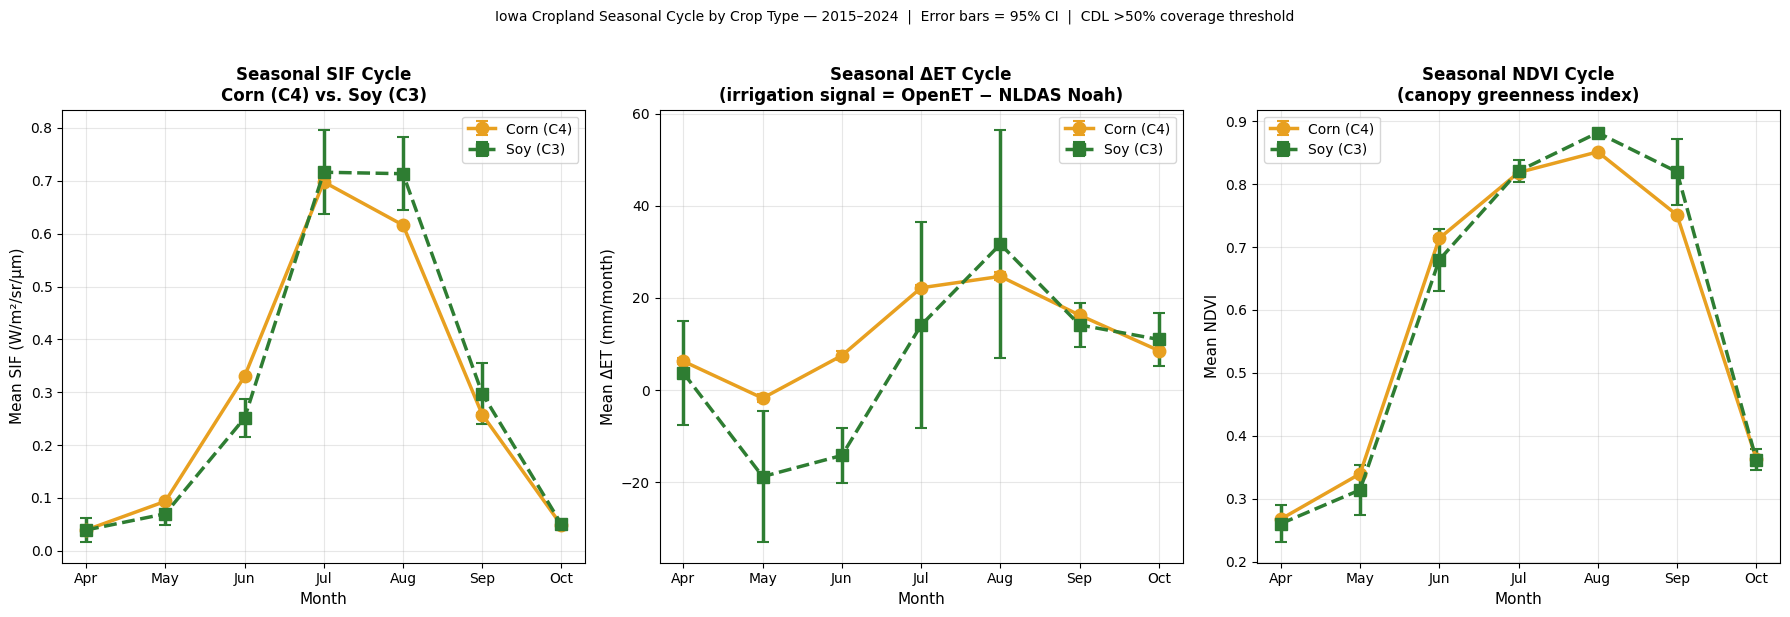

Saved: /home/pielab-sandbox-jcoldiron/SIF-Analysis/figures/sif_irr_drought/corn_soy_seasonal_cycle.png


In [43]:
if df_cs_clean.empty:
    print('Skipping Section 14.2 — no corn/soy data.')
else:
    # Aggregate to monthly means across all years (growing season Apr–Oct)
    month_names_short = {4:'Apr', 5:'May', 6:'Jun', 7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct'}

    # Mean ± SEM per [crop_type × month] — pooled across all 10 years
    seasonal = (df_cs_clean.groupby(['crop_type', 'month'])[['sif', 'et', 'ndvi']]
                .agg(['mean', 'sem']).reset_index())
    seasonal.columns = ['_'.join(c).strip('_') for c in seasonal.columns]

    crop_colors = {'Corn (C4)': '#e8a020',   # amber/gold for corn
                   'Soy (C3)':  '#2e7d32'}    # deep green for soy
    crop_ls     = {'Corn (C4)': '-',  'Soy (C3)': '--'}
    crop_marker = {'Corn (C4)': 'o',  'Soy (C3)': 's'}

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    gs_months = sorted(df_cs_clean['month'].unique())

    for ax, var, sem_col, ylabel, title in [
        (axes[0], 'sif_mean', 'sif_sem',
         'Mean SIF (W/m²/sr/µm)',
         'Seasonal SIF Cycle\nCorn (C4) vs. Soy (C3)'),
        (axes[1], 'et_mean',  'et_sem',
         'Mean ΔET (mm/month)',
         'Seasonal ΔET Cycle\n(irrigation signal = OpenET − NLDAS Noah)'),
        (axes[2], 'ndvi_mean','ndvi_sem',
         'Mean NDVI',
         'Seasonal NDVI Cycle\n(canopy greenness index)'),
    ]:
        for crop in ['Corn (C4)', 'Soy (C3)']:
            sub = seasonal[seasonal['crop_type'] == crop].sort_values('month')
            if sub.empty:
                continue
            ax.errorbar(
                sub['month'], sub[var],
                yerr=1.96 * sub[sem_col],
                label=crop,
                color=crop_colors[crop],
                linestyle=crop_ls[crop],
                marker=crop_marker[crop],
                linewidth=2.5, markersize=9,
                capsize=4, capthick=1.5,
            )

        ax.set_xticks(gs_months)
        ax.set_xticklabels([month_names_short[m] for m in gs_months], fontsize=10)
        ax.set_xlabel('Month', fontsize=11)
        ax.set_ylabel(ylabel, fontsize=11)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)

    plt.suptitle(
        f'Iowa Cropland Seasonal Cycle by Crop Type — {YEARS[0]}–{YEARS[-1]}  |  '
        f'Error bars = 95% CI  |  CDL >50% coverage threshold',
        fontsize=10, y=1.02
    )
    plt.tight_layout()
    plt.savefig(figures_dir / 'corn_soy_seasonal_cycle.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {figures_dir}/corn_soy_seasonal_cycle.png')

### 14.3 SIF and ΔET Response to Drought — Corn vs. Soy

How does each crop type respond to drought, and does their irrigation demand differ
under drought conditions?

**Left panel — SIF z-score by drought:** If corn is more drought-tolerant (C4 water use
efficiency) or more heavily irrigated, corn SIF should remain closer to its seasonal
average under higher drought categories relative to soy.

**Right panel — ΔET by drought:** Do farmers apply more water to corn or soy under
drought stress? In Iowa, corn is the higher-value crop and has a more developed
irrigation infrastructure in western Iowa. If corn receives significantly more
irrigation (higher ΔET) than soy, that would explain any observed drought resilience.

**Bottom panel — SIF vs. ΔET scatter by crop type:** Direct relationship between
the irrigation signal and productivity for each crop type, revealing whether the
marginal return on irrigation (SIF per mm of ΔET) differs between corn and soy.

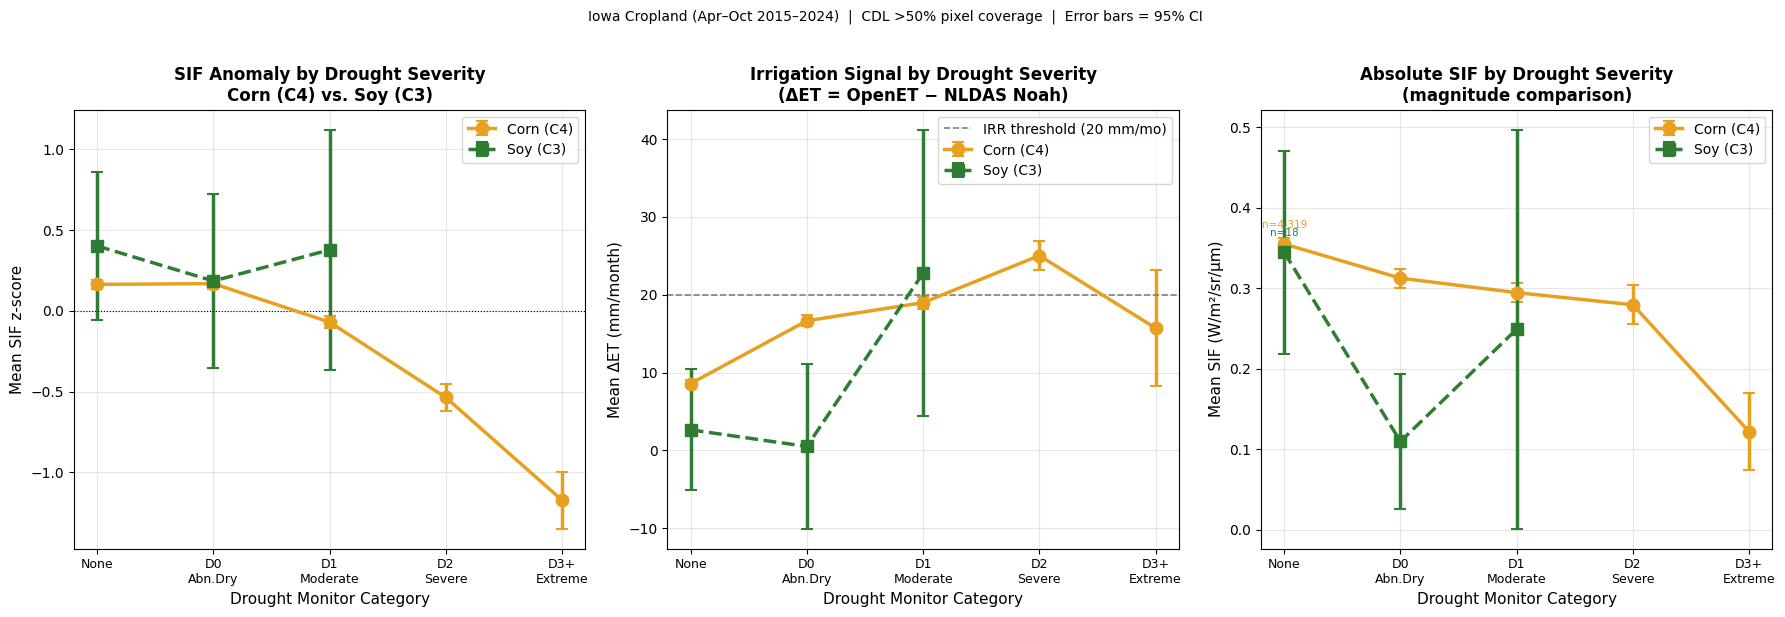

Saved: /home/pielab-sandbox-jcoldiron/SIF-Analysis/figures/sif_irr_drought/corn_soy_drought_response.png


In [44]:
if df_cs_clean.empty:
    print('Skipping Section 14.3 — no corn/soy data.')
else:
    cs_present_cats = sorted(df_cs_clean['dm_cat'].unique())
    cs_cat_labels   = [DM_LABELS[c] for c in cs_present_cats]

    # ── Compute group means × drought category for SIF and ΔET ───────────────
    cs_sifz = (df_cs_clean.groupby(['crop_type', 'dm_cat'])['sif_z']
               .agg(['mean', 'sem', 'count']).reset_index())
    cs_et   = (df_cs_clean.groupby(['crop_type', 'dm_cat'])['et']
               .agg(['mean', 'sem', 'count']).reset_index())
    cs_sif_abs = (df_cs_clean.groupby(['crop_type', 'dm_cat'])['sif']
                  .agg(['mean', 'sem']).reset_index())

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # ── Left: SIF z-score by drought × crop type ─────────────────────────────
    ax = axes[0]
    for crop in ['Corn (C4)', 'Soy (C3)']:
        sub = cs_sifz[cs_sifz['crop_type'] == crop].sort_values('dm_cat')
        if sub.empty: continue
        ax.errorbar(
            sub['dm_cat'], sub['mean'], yerr=1.96 * sub['sem'],
            label=crop, color=crop_colors[crop],
            marker=crop_marker[crop], linestyle=crop_ls[crop],
            linewidth=2.5, markersize=9, capsize=4, capthick=1.5,
        )
    ax.axhline(0, color='black', lw=0.8, ls=':')
    ax.set_xticks(cs_present_cats)
    ax.set_xticklabels(cs_cat_labels, fontsize=9)
    ax.set_xlabel('Drought Monitor Category', fontsize=11)
    ax.set_ylabel('Mean SIF z-score', fontsize=11)
    ax.set_title('SIF Anomaly by Drought Severity\nCorn (C4) vs. Soy (C3)',
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    # ── Middle: ΔET by drought × crop type ────────────────────────────────────
    ax = axes[1]
    for crop in ['Corn (C4)', 'Soy (C3)']:
        sub = cs_et[cs_et['crop_type'] == crop].sort_values('dm_cat')
        if sub.empty: continue
        ax.errorbar(
            sub['dm_cat'], sub['mean'], yerr=1.96 * sub['sem'],
            label=crop, color=crop_colors[crop],
            marker=crop_marker[crop], linestyle=crop_ls[crop],
            linewidth=2.5, markersize=9, capsize=4, capthick=1.5,
        )
    ax.axhline(IRR_THRESHOLD_MM, color='gray', lw=1.2, ls='--',
               label=f'IRR threshold ({IRR_THRESHOLD_MM:.0f} mm/mo)')
    ax.set_xticks(cs_present_cats)
    ax.set_xticklabels(cs_cat_labels, fontsize=9)
    ax.set_xlabel('Drought Monitor Category', fontsize=11)
    ax.set_ylabel('Mean ΔET (mm/month)', fontsize=11)
    ax.set_title('Irrigation Signal by Drought Severity\n(ΔET = OpenET − NLDAS Noah)',
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    # ── Right: absolute SIF by drought × crop type ────────────────────────────
    ax = axes[2]
    for crop in ['Corn (C4)', 'Soy (C3)']:
        sub = cs_sif_abs[cs_sif_abs['crop_type'] == crop].sort_values('dm_cat')
        if sub.empty: continue
        ax.errorbar(
            sub['dm_cat'], sub['mean'], yerr=1.96 * sub['sem'],
            label=crop, color=crop_colors[crop],
            marker=crop_marker[crop], linestyle=crop_ls[crop],
            linewidth=2.5, markersize=9, capsize=4, capthick=1.5,
        )
        # Annotate n at the no-drought point for reference
        no_drought = sub[sub['dm_cat'] == 0]
        if not no_drought.empty:
            n = cs_sifz.loc[(cs_sifz['crop_type'] == crop) & (cs_sifz['dm_cat'] == 0), 'count']
            n_val = int(n.iloc[0]) if len(n) else 0
            ax.annotate(f'n={n_val:,}',
                        xy=(0, float(no_drought['mean'].iloc[0])),
                        xytext=(0, float(no_drought['mean'].iloc[0]) + 0.02),
                        ha='center', fontsize=7.5, color=crop_colors[crop])

    ax.set_xticks(cs_present_cats)
    ax.set_xticklabels(cs_cat_labels, fontsize=9)
    ax.set_xlabel('Drought Monitor Category', fontsize=11)
    ax.set_ylabel('Mean SIF (W/m²/sr/µm)', fontsize=11)
    ax.set_title('Absolute SIF by Drought Severity\n(magnitude comparison)',
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    plt.suptitle(
        f'Iowa Cropland (Apr–Oct {YEARS[0]}–{YEARS[-1]})  |  '
        f'CDL >50% pixel coverage  |  Error bars = 95% CI',
        fontsize=10, y=1.02
    )
    plt.tight_layout()
    plt.savefig(figures_dir / 'corn_soy_drought_response.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {figures_dir}/corn_soy_drought_response.png')

### 14.4 SIF Z-Score Time Series by Crop Type — Year-by-Year Pattern

Year-by-year comparison of Iowa-mean SIF anomaly for corn vs. soy over the 10-year
study period. This reveals whether the two crops respond differently to specific drought
events and whether the SIF gap between them is consistent or event-dependent.

**What to watch for:**
- **2012-era drought:** Iowa experienced a severe multi-state drought in 2012. If SIF
  records extend back to 2012 there should be a clear simultaneous dip in both crops.
- **Year-to-year separation:** A persistent offset between corn and soy SIF z-scores
  would suggest systematic differences in drought tolerance or irrigation management
  beyond what the seasonal cycle shows.
- **Convergence under extreme drought:** If very severe drought overwhelms both C4 and
  C3 advantages, the two curves should converge at the bottom of the plot.

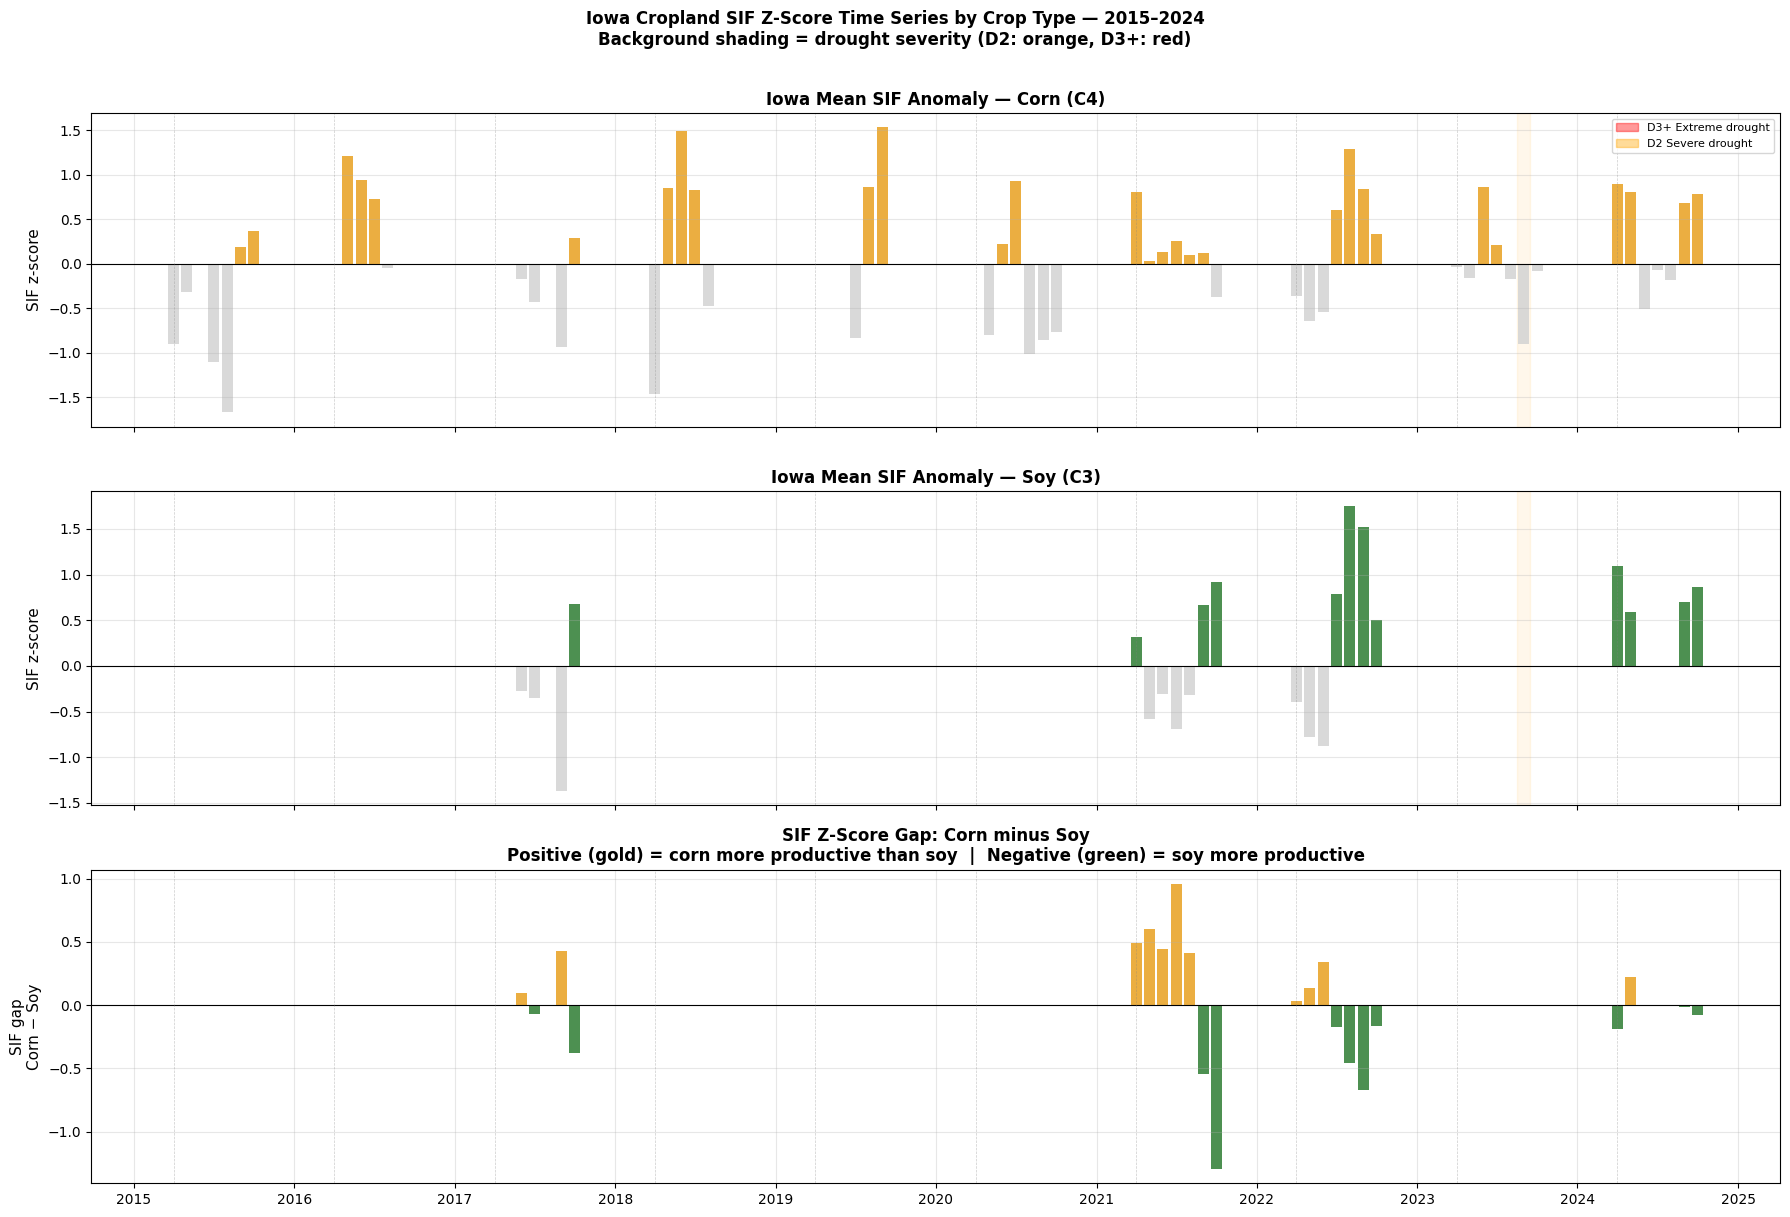

Saved: /home/pielab-sandbox-jcoldiron/SIF-Analysis/figures/sif_irr_drought/corn_soy_sif_timeseries.png


In [45]:
if df_cs_clean.empty:
    print('Skipping Section 14.4 — no corn/soy data.')
else:
    # Iowa spatial mean SIF z-score for corn and soy pixels, per month
    # This reuses df_cs_clean (already growing-season, valid SIF)
    cs_ts = (df_cs_clean.groupby(['crop_type', 'yyyymm'])['sif_z']
             .mean().reset_index())
    cs_ts['date'] = pd.to_datetime(cs_ts['yyyymm'], format='%Y%m')
    cs_ts = cs_ts.sort_values(['crop_type', 'date'])

    # ── Drought background shading ─────────────────────────────────────────────
    # Use ts_df (Section 7) for Iowa-wide mean drought severity per month
    dm_ts = ts_df[['date', 'dm_mean']].dropna()

    fig, axes = plt.subplots(3, 1, figsize=(18, 12), sharex=True)

    # ── Panel 1: Corn SIF z-score ──────────────────────────────────────────────
    for ax_i, (crop, color, title_suffix) in enumerate([
        ('Corn (C4)', crop_colors['Corn (C4)'], 'Corn (C4)'),
        ('Soy (C3)',  crop_colors['Soy (C3)'],  'Soy (C3)'),
    ]):
        ax = axes[ax_i]
        sub = cs_ts[cs_ts['crop_type'] == crop]
        vals = sub['sif_z'].fillna(0)
        bar_colors = [color if v >= 0 else 'lightgray' for v in vals]

        ax.bar(sub['date'], sub['sif_z'], width=25, color=bar_colors, alpha=0.85)
        ax.axhline(0, color='black', lw=0.8)
        ax.set_ylabel('SIF z-score', fontsize=11)
        ax.set_title(f'Iowa Mean SIF Anomaly — {title_suffix}', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)

        # Drought severity as hatched background shading (D2+ = orange, D3+ = red)
        for _, dm_row in dm_ts.iterrows():
            dm_val = dm_row['dm_mean']
            if dm_val >= 3:   # D3+ Extreme
                ax.axvspan(dm_row['date'] - pd.Timedelta(days=15),
                           dm_row['date'] + pd.Timedelta(days=15),
                           alpha=0.12, color='red', zorder=0)
            elif dm_val >= 2:  # D2 Severe
                ax.axvspan(dm_row['date'] - pd.Timedelta(days=15),
                           dm_row['date'] + pd.Timedelta(days=15),
                           alpha=0.08, color='orange', zorder=0)

    # ── Panel 3: Corn − Soy SIF gap ───────────────────────────────────────────
    ax = axes[2]
    # Pivot to wide to compute the crop-type difference
    cs_wide = cs_ts.pivot(index='date', columns='crop_type', values='sif_z')
    if 'Corn (C4)' in cs_wide and 'Soy (C3)' in cs_wide:
        cs_wide['gap'] = cs_wide['Corn (C4)'] - cs_wide['Soy (C3)']
        gap_colors = ['#e8a020' if v >= 0 else '#2e7d32' for v in cs_wide['gap'].fillna(0)]
        ax.bar(cs_wide.index, cs_wide['gap'], width=25, color=gap_colors, alpha=0.85)
        ax.axhline(0, color='black', lw=0.8)
        ax.set_ylabel('SIF gap\nCorn − Soy', fontsize=11)
        ax.set_title('SIF Z-Score Gap: Corn minus Soy\n'
                     'Positive (gold) = corn more productive than soy  '
                     '|  Negative (green) = soy more productive',
                     fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)

    # Year dividers + drought legend
    drought_patches = [
        mpatches.Patch(color='red',    alpha=0.4, label='D3+ Extreme drought'),
        mpatches.Patch(color='orange', alpha=0.4, label='D2 Severe drought'),
    ]
    for year in YEARS:
        for a in axes:
            a.axvline(pd.Timestamp(f'{year}-04-01'), color='gray', lw=0.5, ls='--', alpha=0.4)
    axes[0].legend(handles=drought_patches, fontsize=8, loc='upper right')

    plt.suptitle(
        f'Iowa Cropland SIF Z-Score Time Series by Crop Type — {YEARS[0]}–{YEARS[-1]}\n'
        'Background shading = drought severity (D2: orange, D3+: red)',
        fontsize=12, fontweight='bold', y=1.01
    )
    plt.tight_layout()
    plt.savefig(figures_dir / 'corn_soy_sif_timeseries.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {figures_dir}/corn_soy_sif_timeseries.png')

## 15. Summary

This section prints a comprehensive summary of the key quantitative results from all
analysis sections, suitable for use as a quick reference or for extracting numbers
into a write-up.

**Organized by:**
1. Dataset coverage and completeness
2. Irrigation classification breakdown
3. SIF drought response by irrigation group (core result)
4. NDVI availability and fallow statistics
5. Corn vs. Soy summary statistics

In [46]:
sep  = '─' * 65
sep2 = '═' * 65

print(sep2)
print('  SIF × IRRIGATION × DROUGHT — IOWA 2015–2024')
print('  Analysis Summary')
print(sep2)

# ── 1. Dataset coverage ───────────────────────────────────────────────────────
print('\n1. DATASET COVERAGE')
print(sep)
n_et_avail = int((~np.isnan(et_cube)).any(axis=(1, 2)).sum())
n_sif_avail = int((~np.isnan(sif_cube)).any(axis=(1, 2)).sum())
n_ndvi_avail_s = int((~np.isnan(ndvi_cube)).any(axis=(1, 2)).sum())
n_drought_avail = int((~np.isnan(drought_cube)).any(axis=(1, 2)).sum())
print(f'  Study period:        {YEARS[0]}–{YEARS[-1]} ({len(YEARS)*12} months)')
print(f'  Iowa grid:           {iowa_shape[0]} rows × {iowa_shape[1]} cols '
      f'(0.125° NLDAS)')
print(f'  ΔET months loaded:   {n_et_avail}/{len(YEARS)*12}')
print(f'  SIF months loaded:   {n_sif_avail}/{len(YEARS)*12}')
print(f'  NDVI months loaded:  {n_ndvi_avail_s}/{len(YEARS)*12}')
print(f'  Drought months:      {n_drought_avail}/{len(YEARS)*12}')

# ── 2. Irrigation classification ──────────────────────────────────────────────
print(f'\n2. IRRIGATION CLASSIFICATION  (threshold: ΔET > {IRR_THRESHOLD_MM} mm/month)')
print(sep)
if not df_gs_clean.empty:
    n_total = len(df_gs_clean)
    n_high  = (df_gs_clean['irr_group'] == HIGH_GROUP).sum()
    n_low   = n_total - n_high
    print(f'  Growing-season pixel-months (SIF valid):  {n_total:,}')
    print(f'  High-confidence irrigation:    {n_high:,}  ({100*n_high/n_total:.1f}%)')
    print(f'  Low-confidence / no irrig.:    {n_low:,}  ({100*n_low/n_total:.1f}%)')
    print(f'  Mean ΔET (all):       {df_gs_clean["et"].mean():+.1f} mm/month')
    print(f'  Mean ΔET (High):      {df_gs_clean.loc[df_gs_clean["irr_group"]==HIGH_GROUP,"et"].mean():+.1f} mm/month')
    print(f'  Mean ΔET (Low):       {df_gs_clean.loc[df_gs_clean["irr_group"]==LOW_GROUP,"et"].mean():+.1f} mm/month')

# ── 3. SIF drought response ────────────────────────────────────────────────────
print(f'\n3. SIF DROUGHT RESPONSE BY IRRIGATION GROUP')
print(sep)
if not df_gs_clean.empty:
    # Reproduce the key cross-tab
    sif_cross = (df_gs_clean.groupby(['irr_group', 'dm_cat'])['sif_z']
                 .mean().unstack('dm_cat').round(3))
    print('  Mean SIF z-score (rows = irr. group, cols = DM category):')
    print(sif_cross.to_string())
    if not gap_df.empty:
        print(f'\n  Irrigation buffering gap (High − Low SIF z) by DM category:')
        for _, row in gap_df.iterrows():
            direction = '↑ buffering' if row['gap'] > 0 else '↓ no benefit'
            print(f'    DM {int(row["dm_cat"])} ({DM_LABELS[int(row["dm_cat"])].replace(chr(10)," ")}): '
                  f'gap = {row["gap"]:+.3f}  ±{row["ci"]:.3f}  {direction}')

# ── 4. NDVI ────────────────────────────────────────────────────────────────────
print(f'\n4. NDVI')
print(sep)
print(f'  NDVI months available: {n_ndvi_avail_s}')
if n_ndvi_avail_s > 0 and 'df_gs_ndvi' in dir() and not df_gs_ndvi.empty:
    n_ndvi_total = len(df_gs_ndvi)
    print(f'  NDVI growing-season pixel-months: {n_ndvi_total:,}')
    print(f'  Mean NDVI z-score: {df_gs_ndvi["ndvi_z"].mean():+.3f}')
else:
    print('  No NDVI data available — run 07_download_ndvi_iowa.py first.')

# ── 5. Corn vs. Soy ───────────────────────────────────────────────────────────
print(f'\n5. CORN vs. SOY (CDL > 50% coverage)')
print(sep)
if not df_cs_clean.empty:
    for crop in ['Corn (C4)', 'Soy (C3)']:
        sub = df_cs_clean[df_cs_clean['crop_type'] == crop]
        pct_irr = 100 * (sub['irr_group'] == HIGH_GROUP).mean()
        print(f'  {crop}:')
        print(f'    Pixel-months:  {len(sub):,}')
        print(f'    Mean SIF:      {sub["sif"].mean():.4f} W/m²/sr/µm')
        print(f'    Mean ΔET:      {sub["et"].mean():+.1f} mm/month')
        print(f'    Mean SIF z:    {sub["sif_z"].mean():+.3f}')
        print(f'    % high-irrig.: {pct_irr:.1f}%')
else:
    print('  No corn/soy data available.')

print(f'\n{sep2}')
print(f'  Figures saved to: {figures_dir}')
print(f'{sep2}')

# List all generated figures
saved_figs = sorted(figures_dir.glob('*.png'))
print(f'\n  Figures generated ({len(saved_figs)} total):')
for f in saved_figs:
    print(f'    {f.name}')

═════════════════════════════════════════════════════════════════
  SIF × IRRIGATION × DROUGHT — IOWA 2015–2024
  Analysis Summary
═════════════════════════════════════════════════════════════════

1. DATASET COVERAGE
─────────────────────────────────────────────────────────────────
  Study period:        2015–2024 (120 months)
  Iowa grid:           25 rows × 52 cols (0.125° NLDAS)
  ΔET months loaded:   120/120
  SIF months loaded:   118/120
  NDVI months loaded:  120/120
  Drought months:      101/120

2. IRRIGATION CLASSIFICATION  (threshold: ΔET > 20.0 mm/month)
─────────────────────────────────────────────────────────────────
  Growing-season pixel-months (SIF valid):  28,658
  High-confidence irrigation:    10,044  (35.0%)
  Low-confidence / no irrig.:    18,614  (65.0%)
  Mean ΔET (all):       +14.8 mm/month
  Mean ΔET (High):      +32.7 mm/month
  Mean ΔET (Low):       +5.1 mm/month

3. SIF DROUGHT RESPONSE BY IRRIGATION GROUP
──────────────────────────────────────────────────